In [4]:
# pip install bert-score
# pip install --upgrade pip
# pip install -U sentence-transformers
# pip install sentence-transformers
# pip install tf-keras
# pip install transformers==4.35.2
# pip install -U sentence-transformers
# pip install umap-learn
# pip install pynndescent
# pip install hdbscan
# pip install anytree
# pip install yake
# pip install ollama

In [5]:
# pip install anytree

In [1]:
import os, random
import numpy as np
import pandas as pd
from sklearn.cluster import OPTICS
from sklearn.datasets import make_blobs
from sentence_transformers import SentenceTransformer
from umap import UMAP
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

INPUT_CSV = "/Users/suyashmali/Thesis/LLM/Notebook/Cleaned_Data_Cluster1.csv"
TEXT_COL = "metadata_clean"
LABEL_COL = "Level3"
MIN_SAMPLES = 100
MAX_SAMPLES = 500

# EMBED_MODEL = "all-mpnet-base-v2"
EMBED_MODEL = "all-MiniLM-L6-v2"

/opt/anaconda3/envs/taxonomy_env/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.18) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [7]:
df = pd.read_csv(INPUT_CSV)

def min_max_sample(df, label_col, min_k, max_k, seed=42):
    sampled_groups = []
    for label, g in df.groupby(label_col):
        if len(g) < min_k:
            continue
        n = min(len(g), max_k)
        sampled_groups.append(g.sample(n=n, random_state=seed))
    return pd.concat(sampled_groups).reset_index(drop=True)

sample_df = min_max_sample(df, LABEL_COL, MIN_SAMPLES, MAX_SAMPLES)

print("Final sample size:", len(sample_df))
print("Unique Level3 categories:", sample_df[LABEL_COL].nunique())

print(sample_df[[LABEL_COL]].value_counts().head(25))

Final sample size: 43803
Unique Level3 categories: 126
Level3                         
Wireless Routers                   500
Power Banks                        500
Network Switches                   500
Projector Mounts                   500
Projector Lamps                    500
Household Batteries                500
IT Support Services                500
Projector Accessories              500
Projection Screens                 500
Power Supply Units                 500
Power Distribution Units (PDUs)    500
Power Cables                       500
KVM Switches                       500
Keyboards                          500
Power Adapters & Inverters         500
Flat Panel Spare Parts             500
Portable Speakers                  500
PCs/Workstations                   500
Mice                               500
Mobile Device Chargers             500
PC/Workstation Barebones           500
Mobile Device Keyboards            500
Mobile Headsets                    500
Notebooks       

In [8]:
sample_df.columns

Index(['Brand', 'BrandPartCode', 'ProductName', 'Description.LongProductName',
       'Description.LongDesc', 'SummaryDescription.LongSummaryDescription',
       'pathlist_names', 'Level1', 'Level2', 'Level3', 'metadata_text',
       'metadata_clean', 'final_text'],
      dtype='object')

In [9]:
sample_df.head()

,Brand,BrandPartCode,ProductName,Description.LongProductName,Description.LongDesc,SummaryDescription.LongSummaryDescription,pathlist_names,Level1,Level2,Level3,metadata_text,metadata_clean,final_text
0,Vertiv,EMS1000T-201,EMS1000T,EMS1000 Media Streamer (Transmitter),<b>Extend stereo audio and high resolution ana...,"Vertiv EMS1000T, Avocent. Type: AV transmitter...",Computers & Electronics>Consumer Audio & Video...,Computers & Electronics,Consumer Audio & Video Equipment,AV Extenders,"Vertiv EMS1000T, Avocent. Type: AV transmitter...","vertiv ems1000t, avocent. type av transmitter,...",av extenders vertiv ems1000t avocent type av t...
1,C2G,29225,29225,TruLink Single Gang HDMI+RS232 over Cat5 Wall ...,The TruLink® HDMI+RS232 over Cat5 allows you t...,"C2G 29225. Type: AV transmitter, Maximum resol...",Computers & Electronics>Consumer Audio & Video...,Computers & Electronics,Consumer Audio & Video Equipment,AV Extenders,"C2G 29225. Type: AV transmitter, Maximum resol...","c2g 29225. type av transmitter, maximum resolu...",av extenders c2g type av transmitter maximum r...
2,StarTech.com,ST128UTPE,8 Port VGA Video Extender over Cat 5 (UTPE Ser...,StarTech.com 8 Port VGA Video Extender over Ca...,The ST128UTPE 8 Port VGA Video Extender over C...,StarTech.com 8 Port VGA Video Extender over Ca...,Computers & Electronics>Consumer Audio & Video...,Computers & Electronics,Consumer Audio & Video Equipment,AV Extenders,StarTech.com 8 Port VGA Video Extender over Ca...,startech.com 8 port vga video extender over ca...,av extenders startech com port video extender ...
3,Tripp Lite,B130-101S-2,"VGA with RS232 over Cat5 / Cat6 Extender Kit, ...","VGA with RS232 over Cat5 / Cat6 Extender Kit, ...",Tripp Lite's B130-101S-2 allows you to extend ...,Tripp Lite VGA with RS232 over Cat5 / Cat6 Ext...,Computers & Electronics>Consumer Audio & Video...,Computers & Electronics,Consumer Audio & Video Equipment,AV Extenders,Tripp Lite VGA with RS232 over Cat5 / Cat6 Ext...,tripp lite vga with rs232 over cat5 / cat6 ext...,av extenders tripp lite with rs232 over cat5 c...
4,Tripp Lite,B160-001-DPSI,DisplayPort Video + Audio with RS-232 Serial a...,DisplayPort Video + Audio with RS-232 Serial a...,The B160-001-DPSI DisplayPort Video + Audio wi...,Tripp Lite DisplayPort Video + Audio with RS-2...,Computers & Electronics>Consumer Audio & Video...,Computers & Electronics,Consumer Audio & Video Equipment,AV Extenders,Tripp Lite DisplayPort Video + Audio with RS-2...,tripp lite displayport video audio with rs-232...,av extenders tripp lite displayport video audi...


In [10]:
def coverage_by_min_k(df, min_k, level3="Level3", level2="Level2", level1="Level1"):
    # keep only Level3 categories with >= min_k products
    filtered = df.groupby(level3).filter(lambda x: len(x) >= min_k)

    return {
        "min_products": min_k,
        "total_products": len(filtered),
        "unique_Level3": filtered[level3].nunique(),
        "unique_Level2": filtered[level2].nunique(),
        "unique_Level1": filtered[level1].nunique(),
    }


min_values = [0, 20, 40, 45, 50, 70, 100, 150]

coverage_table = pd.DataFrame(
    [coverage_by_min_k(df, k) for k in min_values]
)

coverage_table

,min_products,total_products,unique_Level3,unique_Level2,unique_Level1
0,0,289865,209,14,1
1,20,289725,201,14,1
2,40,288693,165,14,1
3,45,288480,160,14,1
4,50,288247,155,13,1
5,70,287483,142,13,1
6,100,286118,126,13,1
7,150,282935,100,13,1


In [11]:
def dropped_categories(df, min_k, level3="Level3"):
    valid = set(
        df.groupby(level3)
        .filter(lambda x: len(x) >= min_k)[level3]
    )
    all_cats = set(df[level3])
    return all_cats - valid

dropped_categories(df, 100)

{'AV Conferencing Bridges',
 'AV Receivers',
 'Activity Trackers',
 'All-in-One PC/Workstation Mounts & Stands',
 'Audio Turntables',
 'Backpack PCs',
 'Bridges & Repeaters',
 'CPU Holders',
 'CRT TVs',
 'Cable Boots',
 'Cable Protectors',
 'Cable Splitters or Combiners',
 'Car Kits',
 'Cassette Players',
 'Computer TV Tuners',
 'Customer Displays',
 'E-Book Readers',
 'Fax Supplies',
 'Fibre Optic Adapters',
 'FireWire Cables',
 'Gateways/Controllers',
 'Handheld Mobile Computer Spare Parts',
 'Handheld Mobile Computers',
 'Head-Mounted Displays',
 'ISDN Access Devices',
 'IT Courses',
 'KVM Extenders',
 "Kids' Tablet Accessories",
 "Kids' Tablets",
 'Lamination Films',
 'Laminator Pouches',
 'MP3/MP4 Player Accessories',
 'Mobile Device Skins',
 'Modems',
 'Monitors CRT',
 'Network Cable Testers',
 'Network Extenders',
 'Network Management Devices',
 'Network Splitters',
 'Network Switch Modules',
 'Notebook Power Tips',
 'Numeric Keypads',
 'Other Input Devices',
 'PS/2 Cables',
 'P

In [12]:
print(sample_df[[LABEL_COL]].value_counts().head(130))

Level3                        
Wireless Routers                  500
Power Banks                       500
Network Switches                  500
Projector Mounts                  500
Projector Lamps                   500
                                 ... 
Portable Stereo Systems           108
Composite Video Cables            106
Component (YPbPr) Video Cables    104
Mobile Phone Cables               103
Input Device Accessories          100
Name: count, Length: 126, dtype: int64


In [13]:
# sample_df["final_text"] = (
#     sample_df[TEXT_COL]
#     .fillna("")
#     .astype(str)
#     .str.strip()
# )

# fallback_cols = ["ProductName", "Title"]

# def fallback_text(row):
#     if row["final_text"]:
#         return row["final_text"]
#     return " ".join(
#         str(row[c]) for c in fallback_cols
#         if c in row and pd.notna(row[c])
#     )

# sample_df["final_text"] = sample_df.apply(fallback_text, axis=1)

# print("Non-empty texts:", sample_df["final_text"].astype(bool).sum())

In [14]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option("max_colwidth", None)

In [15]:
sample_df["final_text"].head(2)

0    av extenders vertiv ems1000t avocent type av transmitter maximum resolution x pixels cable types supported cat5 cat5e operating voltage current dimensions wxdxh x weight
1                                                                av extenders c2g type av transmitter maximum resolution x pixels cable types supported cat5 cat5e cat6 weight
Name: final_text, dtype: object

In [16]:
sample_df.head(2)

,Brand,BrandPartCode,ProductName,Description.LongProductName,Description.LongDesc,SummaryDescription.LongSummaryDescription,pathlist_names,Level1,Level2,Level3,metadata_text,metadata_clean,final_text
0,Vertiv,EMS1000T-201,EMS1000T,EMS1000 Media Streamer (Transmitter),"<b>Extend stereo audio and high resolution analog video from a single point to multiple destinations up to 600 feet over CAT 5 cabling, or from point to point up to 600 feet over CAT 5 cabling.</b><br>\n<br>\nThe Avocent Emerge EMS1000T/R and EMS1000P media streamers require no special software or operating system support, just attach the media streamer hardware and this indoor A/V distribution solution is fully functional. The Emerge EMS1000T/R media streamer solution consists of a transmitter and up to 16 receivers. The transmitter is located at the source of the multimedia content. At the destination points, the receivers connect directly into the output devices such as plasma screens, projectors or monitors. The Emerge EMS1000T/R media streamer design guarantees highly reliable transport of high-quality audio and video. With support for full-screen, full-motion video and high-fidelity stereo audio, high-impact content is delivered to the right place at the right time.<br>\n<br>\nIn courtrooms, classrooms or boardrooms, the Emerge EMS1000T/R media streamer fits right in. With its portability and small footprint, it can be quickly plugged in to create a multimedia A/V distribution system. The Emerge EMS1000T/R media streamer is perfect for situations that require easy set up and high quality output.<br>\n<br>\n<b>Reliable, Cost-Efficient Digital Signage</b><br>\n<br>\nAs an indoor only solution, the design of the Emerge EMS1000T/R and EMS1000P media streamers guarantee highly reliable, high quality audio and video for digital signage installations. With support for full screen, full motion video along with high fidelity stereo audio, high impact digital signage content is securely delivered to the right place at the right time. The Emerge EMS1000T/R and EMS1000P media streamers take advantage of the distance and reliability characteristics inherent with CAT 5 cabling and gets the message from source to destination up to 600 feet apart.<br>\n<br>\n<b>Sensible, Low Cost A/V Extension & Connectivity</b><br>\n<br>\nIn courtrooms, classrooms or boardrooms, the Emerge EMS1000T/R and EMS1000P media streamers fit right in. With its portability and small footprint, it can be quickly plugged in to create a multimedia A/V distribution system. Perfect for situations that require immediate A/V extension with easy set up and high quality output.","Vertiv EMS1000T, Avocent. Type: AV transmitter, Maximum resolution: 1600 x 1200 pixels, Cable types supported: Cat5,Cat5e. Operating voltage: 5.3 V, Current: 1 A. Dimensions (WxDxH): 98 x 95 x 25 mm, Weight: 1.13 kg",Computers & Electronics>Consumer Audio & Video Equipment>AV Extenders,Computers & Electronics,Consumer Audio & Video Equipment,AV Extenders,"Vertiv EMS1000T, Avocent. Type: AV transmitter, Maximum resolution: 1600 x 1200 pixels, Cable types supported: Cat5,Cat5e. Operating voltage: 5.3 V, Current: 1 A. Dimensions (WxDxH): 98 x 95 x 25 mm, Weight: 1.13 kg","vertiv ems1000t, avocent. type av transmitter, maximum resolution 1600 x 1200 pixels, cable types supported cat5,cat5e. operating voltage 5.3 v, current 1 a. dimensions wxdxh 98 x 95 x 25 mm, weight 1.13 kg",av extenders vertiv ems1000t avocent type av transmitter maximum resolution x pixels cable types supported cat5 cat5e operating voltage current dimensions wxdxh x weight
1,C2G,29225,29225,TruLink Single Gang HDMI+RS232 over Cat5 Wall Plate Transmitter- Aluminum,"The TruLink® HDMI+RS232 over Cat5 allows you to extend HDMI+RS232 signals over a single Cat5/Cat5e/Cat6 unshielded twisted pair cables up to 300ft without signal degradation at 1920x1200 or 1920x1080 resolutions*. This solution is compatible with any operating system and is truly plug and play with no dri

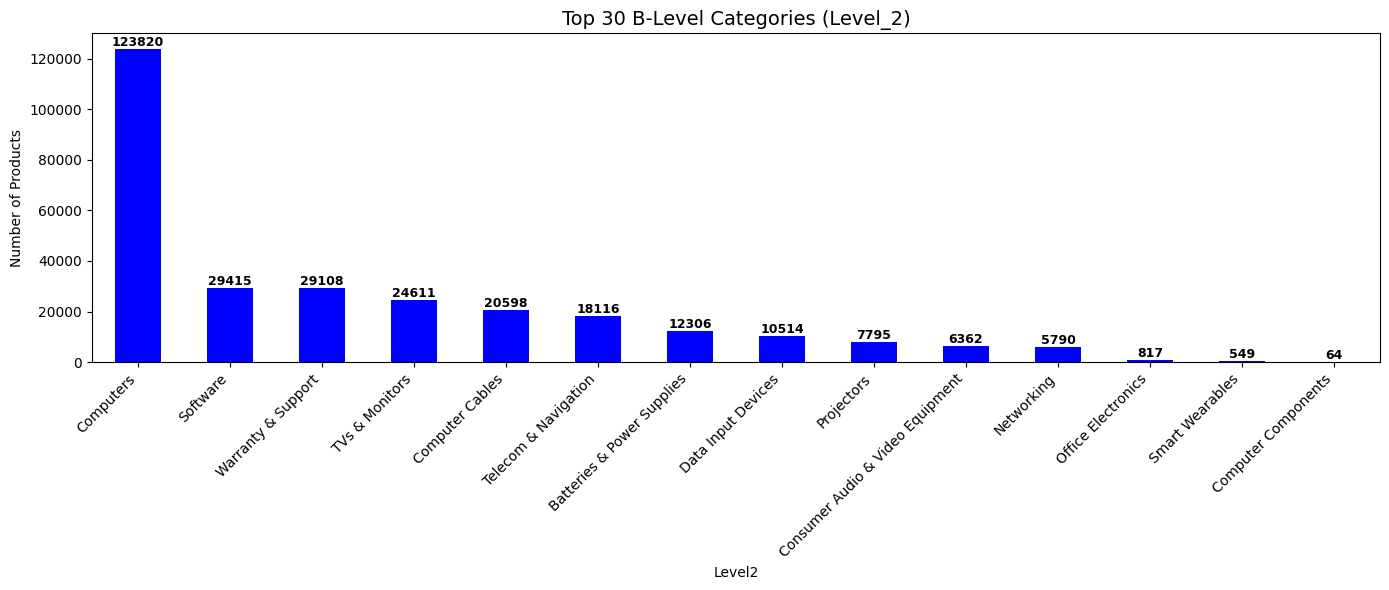

In [17]:
import matplotlib.pyplot as plt

# Count Level_2 categories
b_counts = df['Level2'].value_counts()

# Plot Top 20
plt.figure(figsize=(14, 6))
ax = b_counts.head(30).plot(kind='bar', color='blue')

# Add labels on top of bars
for i, count in enumerate(b_counts.head(30).values):
    ax.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title("Top 30 B-Level Categories (Level_2)", fontsize=14)
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

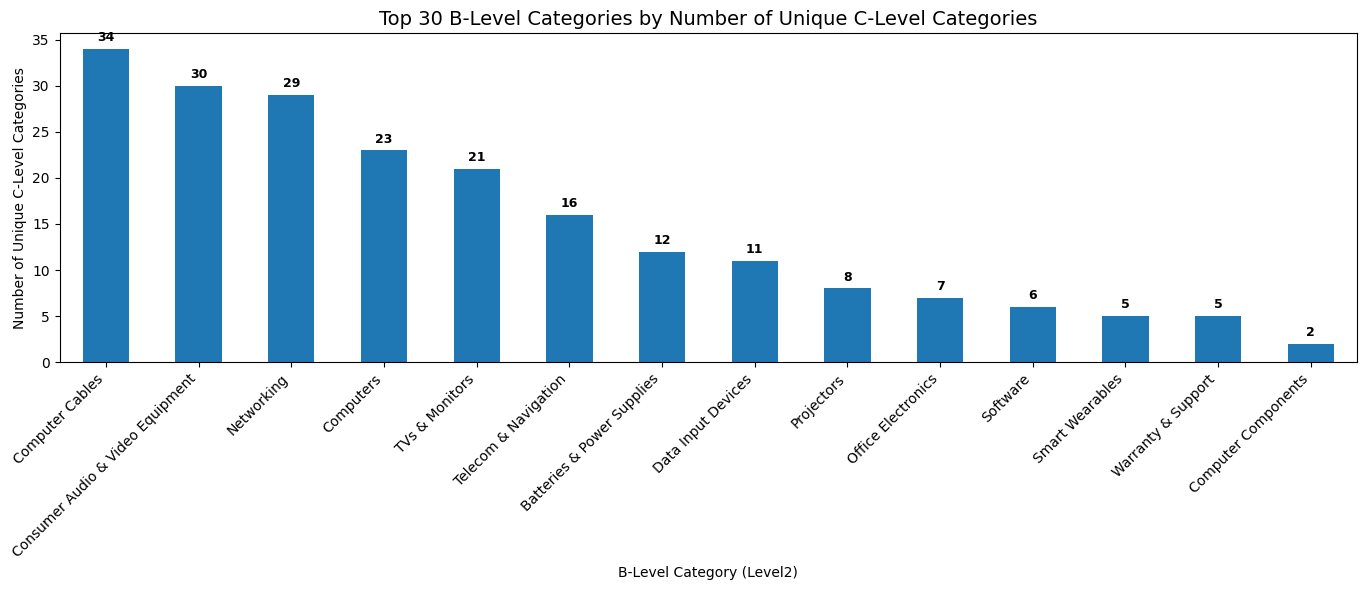

In [18]:
import matplotlib.pyplot as plt

# Count unique C-level categories per B-level
b_c_unique = (
    df.groupby("Level2")["Level3"]
    .nunique()
    .sort_values(ascending=False)
)

# Plot Top 30 B-levels by number of unique C-levels
plt.figure(figsize=(14, 6))
ax = b_c_unique.head(30).plot(kind='bar')

# Add labels on top of bars
for i, count in enumerate(b_c_unique.head(30).values):
    ax.text(i, count + 0.5, str(count), ha='center', va='bottom',
            fontsize=9, fontweight='bold')

plt.title("Top 30 B-Level Categories by Number of Unique C-Level Categories", fontsize=14)
plt.ylabel("Number of Unique C-Level Categories")
plt.xlabel("B-Level Category (Level2)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [19]:
# sample_df[sample_df["ProductName"] == "EMS1000T"][["ProductName", "metadata_clean", "final_text"]]

In [20]:
# Sentence Embeddings

model = SentenceTransformer(EMBED_MODEL)

embeddings = model.encode(
    sample_df["metadata_clean"].tolist(),
    batch_size = 128,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Embedding shape:", embeddings.shape)

Batches:   0%|          | 0/343 [00:00<?, ?it/s]

Embedding shape: (43803, 384)


In [21]:
umap_model = UMAP(
    n_neighbors=50,
    min_dist=0.0,
    n_components=50,
    # n_components=10,
    metric="cosine",
    random_state=RANDOM_STATE
)

reduced = umap_model.fit_transform(embeddings)
print("Reduced shape:", reduced.shape)

/opt/anaconda3/envs/taxonomy_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced shape: (43803, 50)


In [22]:
optics = OPTICS(
    min_samples=15,
    metric="euclidean",
    cluster_method="xi",
    xi=0.05, 
    min_cluster_size = 100
)

sample_df["C_id_optics"] = optics.fit_predict(reduced)

print("Clusters formed:", sample_df["C_id_optics"].nunique())
print(sample_df["C_id_optics"].value_counts().head(10))

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Clusters formed: 164
C_id_optics
-1      21462
 51       500
 31       403
 13       292
 125      247
 14       232
 55       231
 132      225
 39       224
 1        222
Name: count, dtype: int64


In [23]:
# Evaluation (NO NOISE)
mask = sample_df["C_id_optics"] != -1

ari = adjusted_rand_score(
    sample_df.loc[mask, LABEL_COL],
    sample_df.loc[mask, "C_id_optics"]
)

nmi = normalized_mutual_info_score(
    sample_df.loc[mask, LABEL_COL],
    sample_df.loc[mask, "C_id_optics"]
)

print("ARI:", round(ari, 4))
print("NMI:", round(nmi, 4))

ARI: 0.5714
NMI: 0.845


In [24]:
noise_ratio = (sample_df["C_id_optics"] == -1).mean()

print("Noise Ratio:", round(noise_ratio, 4))

Noise Ratio: 0.49


In [25]:

def cluster_purity(df, cluster_col, gold_col):
    stats = (
        df.groupby(cluster_col)[gold_col]
        .value_counts()
        .rename("count")
        .reset_index()
    )
    top = stats.groupby(cluster_col).first().reset_index()
    sizes = df[cluster_col].value_counts().rename("size").reset_index()
    merged = top.merge(sizes, on=cluster_col)
    merged["purity"] = merged["count"] / merged["size"]
    return merged.sort_values("purity", ascending=False)

purity_df = cluster_purity(sample_df, "C_id_optics", LABEL_COL)
purity_df.head(160)

,C_id_optics,Level3,count,size,purity
130,129,Thin Clients,102,102,1.000000
141,140,Servers,136,136,1.000000
107,106,Uninterruptible Power Supplies (UPSs),145,145,1.000000
115,114,DVD/Blu-Ray Players,119,119,1.000000
98,97,Data Projectors,133,133,1.000000
119,118,Home Audio Sets,107,107,1.000000
68,67,Remote Controls,111,111,1.000000
123,122,Dictaphones,116,116,1.000000
35,34,Power Banks,173,173,1.000000
95,94,Projector Lamps,118,118,1.000000


In [26]:
sample_df[sample_df["C_id_optics"] == 147][["Brand", "ProductName", LABEL_COL]].head(1000)

,Brand,ProductName,Level3
12504,Samsung,HG55NJ690UF,Hospitality TVs
12507,Samsung,HG48ED670CK,Hospitality TVs
12508,TCL,U55S6806S,Hospitality TVs
12509,Samsung,HG43NJ477MFXZA,Hospitality TVs
12510,Samsung,HG49NJ478MFXZA,Hospitality TVs
12519,Samsung,HG49EF690DB,Hospitality TVs
12520,Samsung,HG55EE890WB,Hospitality TVs
12521,Samsung,HG43NJ478MFXZA,Hospitality TVs
12522,Samsung,40HA670,Hospitality TVs
12523,Samsung,HG32ED450SW,Hospitality TVs


In [27]:
sample_df[sample_df["C_id_optics"] == 162][["Brand", "ProductName", "Level3"]].nunique()

Brand            9
ProductName    118
Level3           2
dtype: int64

In [28]:
example_cluster = sample_df["C_id_optics"].value_counts().index[4]

sample_df[sample_df["C_id_optics"] == example_cluster][["C_id_optics", "Brand", "ProductName", LABEL_COL]].head(100)

,C_id_optics,Brand,ProductName,Level3
18995,125,Logitech,PC 850 Mono Headset,Mobile Headsets
18998,125,Samsung,MA299943,Mobile Headsets
18999,125,TALIUS,HPH-5004BT,Mobile Headsets
19003,125,iggual,PSI09025,Mobile Headsets
19006,125,NGS,Yellow Cougar,Mobile Headsets
19008,125,LG,MA255828,Mobile Headsets
19009,125,LG,HBS-750,Mobile Headsets
19012,125,SilverHT,111763540199,Mobile Headsets
19013,125,HP,H2000,Mobile Headsets
19014,125,NGS,Orange Gumdrop,Mobile Headsets


In [29]:
example_cluster = sample_df["C_id_optics"].value_counts().index[14]

sample_df[sample_df["C_id_optics"] == example_cluster][["Brand", "ProductName", LABEL_COL]]

,Brand,ProductName,Level3
2974,Casio,MS-20NC,Calculators
2979,Casio,SL-100NC,Calculators
2980,Casio,JW-200TV-RD,Calculators
2985,Casio,SL-450L,Calculators
2987,Casio,DR-T220,Calculators
2990,Casio,MS-8VERII,Calculators
2992,Casio,SL-300NC,Calculators
2993,Casio,FX-82ES,Calculators
2994,Casio,HL-4A,Calculators
2999,Casio,Classwiz FX-350EX,Calculators


In [30]:
# Map each cluster to its dominant Level3
cluster_to_label = (
    sample_df
    .groupby("C_id_optics")[LABEL_COL]
    .agg(lambda x: x.value_counts().idxmax())
)

collapsed_preds = sample_df["C_id_optics"].map(cluster_to_label)

adjusted_rand_score(sample_df[LABEL_COL], collapsed_preds)


0.02209524058257721

In [31]:
def cluster_quality(df, cluster_col, gold_col):
    stats = (
        df.groupby(cluster_col)[gold_col]
        .value_counts()
        .rename("count")
        .reset_index()
    )

    sizes = df[cluster_col].value_counts().rename("size").reset_index()
    merged = stats.merge(sizes, on=cluster_col)

    # purity
    top = (
        merged.sort_values("count", ascending=False)
        .groupby(cluster_col)
        .first()
        .reset_index()
    )
    top["purity"] = top["count"] / top["size"]
    top["impurity"] = 1 - top["purity"]

    # entropy
    entropy = (
        merged.assign(p=lambda x: x["count"] / x["size"])
        .groupby(cluster_col)
        .apply(lambda g: -np.sum(g["p"] * np.log(g["p"])))
        .reset_index(name="entropy")
    )

    return top.merge(entropy, on=cluster_col).sort_values("impurity", ascending=False)


In [32]:
quality_df = cluster_quality(sample_df, "C_id_optics", LABEL_COL)

# Worst clusters by impurity
quality_df.head(1000)

/var/folders/b_/cv34fjz13m34nzs9_x_gpp600000gn/T/ipykernel_72911/315832772.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: -np.sum(g["p"] * np.log(g["p"])))


,C_id_optics,Level3,count,size,purity,impurity,entropy
0,-1,Portable Speakers,479,21462,0.022319,0.977681,4.616180
56,55,Flat Panel Desk Mounts,37,231,0.160173,0.839827,2.876521
30,29,HDMI Cables,20,102,0.196078,0.803922,2.582841
131,130,Notebooks,23,115,0.200000,0.800000,2.380991
53,52,Thin Clients,32,138,0.231884,0.768116,2.173488
57,56,Projection Lenses,30,103,0.291262,0.708738,2.291626
91,90,TVs,35,119,0.294118,0.705882,2.327730
93,92,PCs/Workstations,37,119,0.310924,0.689076,1.507746
20,19,Serial Attached SCSI (SAS) Cables,34,106,0.320755,0.679245,2.178973
21,20,Coaxial Cables,37,113,0.327434,0.672566,2.055480


In [ ]:
quality_df_valid = quality_df[quality_df["C_id_optics"] != -1]


In [34]:
overall_purity = (
    (quality_df_valid["purity"] * quality_df_valid["size"]).sum()
    / quality_df_valid["size"].sum()
)

overall_impurity = 1 - overall_purity

print("Overall weighted purity:", round(overall_purity, 4))
print("Overall weighted impurity:", round(overall_impurity, 4))

Overall weighted purity: 0.8203
Overall weighted impurity: 0.1797


In [35]:
example_cluster = sample_df["C_id_optics"].value_counts().index[49]

sample_df[sample_df["C_id_optics"] == example_cluster][["Brand", "ProductName", LABEL_COL]].head(1000)

,Brand,ProductName,Level3
955,Trend Micro,"Worry-Free Business Security 9 Advanced, C-Upg, 51-100U, 1y, ML",Antivirus Security Software
959,Trend Micro,LeakProof 5.0 Advanced,Antivirus Security Software
972,Trend Micro,"Titanium Internet Security 2014, 1Y, 3u, ML",Antivirus Security Software
995,Trend Micro,"Titanium Internet Security 2013, 3u, 1Y, CUPG",Antivirus Security Software
1028,Trend Micro,Antivirus + Security 10,Antivirus Security Software
1039,Trend Micro,"Worry-Free Business Security 9 Advanced, E-Lic, 20U, 1y, ML",Antivirus Security Software
1095,Trend Micro,"Titanium Internet Security 2014, 1Y, 1u, ML",Antivirus Security Software
1128,Trend Micro,Worry-Free Business Security Standard,Antivirus Security Software
1214,Trend Micro,"Worry-Free Business Security 9 Advanced, E-Lic, 5-5U, 1y, ML",Antivirus Security Software
1251,Trend Micro,Maximum Security 2015,Antivirus Security Software


In [36]:
sample_df[sample_df["C_id_optics"] == 49][["Brand", "ProductName", LABEL_COL]].head(1000)

,Brand,ProductName,Level3
11058,Logitech,+tilt,Handheld Device Accessories
11076,Logitech,+tilt,Handheld Device Accessories
11130,Sandberg,Pocket Bluetooth Keyboard UK,Handheld Device Accessories
11138,Sandberg,Mini Bluetooth Keyboard Nordic,Handheld Device Accessories
11141,Logitech,+tilt,Handheld Device Accessories
11206,Logitech,+tilt,Handheld Device Accessories
14020,Logitech,910-005020,Input Device Accessories
14051,Logitech,Ultrathin Keyboard Folio for iPad mini,Input Device Accessories
14074,Logitech,Ultrathin Keyboard Folio for Samsung Galaxy Tab 3 10.1,Input Device Accessories
14080,Logitech,Keyboard Folio for iPad,Input Device Accessories


In [37]:
sample_df[sample_df["C_id_optics"] == 49][["Brand", "ProductName", LABEL_COL]].nunique()

Brand           6
ProductName    75
Level3          6
dtype: int64

In [38]:
sample_df[sample_df["C_id_optics"] == 108][["Brand", "ProductName", LABEL_COL]].nunique()

Brand            5
ProductName    141
Level3           1
dtype: int64

In [39]:
sample_df[sample_df["C_id_optics"] == 108][["Brand", "ProductName", LABEL_COL]].head(1000)

,Brand,ProductName,Level3
27666,Vertiv,PM2012V,Power Distribution Units (PDUs)
27671,Vertiv,GEIST RPDU SWITCHED 0U INPC20 230V 16A OUTP (21)C13,Power Distribution Units (PDUs)
27674,Vertiv,PM3000,Power Distribution Units (PDUs)
27677,Vertiv,"DIS Rack PDU, D, local metered, 0U, input IEC 60309 230V 32A, outputs (18)Schuko",Power Distribution Units (PDUs)
27689,Vertiv,PM1009H,Power Distribution Units (PDUs)
27691,Vertiv,VP4551V,Power Distribution Units (PDUs)
27694,Vertiv,"MPX Rack PDU, input module, metered, 0U, input IEC 60309 230/400V 32A, 3PH",Power Distribution Units (PDUs)
27696,Vertiv,MP2-130P,Power Distribution Units (PDUs)
27698,Vertiv,"MPH2 Rack PDU, outlet metered, 0U, input IEC 60309 230V 16A, output (24)C13",Power Distribution Units (PDUs)
27699,Vertiv,"MPE Rack PDU, elementary, 0U, input IEC 60309 230/400V 3x16A, outputs (18)Schuko",Power Distribution Units (PDUs)


In [40]:
sample_df[sample_df["ProductName"] == "CUSTOM-SIGNAGEPLAYER"][["metadata_clean", "final_text"]]

,metadata_clean,final_text
24373,advantech custom-signageplayer,pc workstation barebones advantech custom signageplayer


In [41]:
df_valid = sample_df[sample_df["C_id_optics"] != -1].copy()

print("Products used for taxonomy:", len(df_valid))
print("C-level clusters:", df_valid["C_id_optics"].nunique())

Products used for taxonomy: 22341
C-level clusters: 163


In [128]:
# ════════════════════════════════════════════════════════════
# CELL 2 — Make sure df_valid was built correctly
# If you are unsure, rebuild it cleanly right here
# ════════════════════════════════════════════════════════════

# This is the single correct definition of df_valid
# Run this before ANY naming or evaluation step

df_valid = sample_df[sample_df["C_id_optics"] != -1].copy()
df_noise = sample_df[sample_df["C_id_optics"] == -1].copy()

print(f"df_valid : {len(df_valid):,} products  across {df_valid['C_id_optics'].nunique()} C clusters")
print(f"df_noise : {len(df_noise):,} products  (excluded from all naming and evaluation)")

# Sanity check — no cluster ID -1 in df_valid
assert (df_valid["C_id_optics"] == -1).sum() == 0
print("\n✅ Clean split confirmed")

df_valid : 22,341 products  across 163 C clusters
df_noise : 21,462 products  (excluded from all naming and evaluation)

✅ Clean split confirmed


In [42]:
def sample_texts_per_cluster(
    df,
    cluster_col,
    text_col,
    n_samples=30,
    seed=42
):
    sampled = {}
    for cid, g in df.groupby(cluster_col):
        n = min(len(g), n_samples)
        sampled[cid] = g.sample(n=n, random_state=seed)[text_col].tolist()
    return sampled

c_cluster_texts = sample_texts_per_cluster(
    df_valid,
    cluster_col="C_id_optics",
    text_col="metadata_clean",
    n_samples=30
)

len(c_cluster_texts)

163

In [43]:
def make_evidence(subdf, max_items=40, max_len=180):
    texts = (
        subdf["metadata_text"]
        .dropna()
        .sample(min(len(subdf), max_items), random_state=42)
        .tolist()
    )
    return "\n".join(t[:max_len] for t in texts)

In [44]:
pip install llama-stack

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [45]:
import bitsandbytes
print(bitsandbytes.__version__)  # should be >= 0.39.0

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


0.49.2


In [ ]:
# # ============================================================
# # CELL 1 — Fixed Ollama verification
# # ============================================================
# import os
# os.environ["TOKENIZERS_PARALLELISM"] = "false"  # suppress the fork warning

# import ollama

# try:
#     models_response = ollama.list()
    
#     # Newer ollama client returns objects, not dicts
#     # Handle both formats safely
#     models = models_response.get("models", []) if isinstance(models_response, dict) else list(models_response)
    
#     print("✅ Ollama is running.")
#     print("Raw response type:", type(models_response))
#     print("Models found:", models_response)  # print raw so we can see exact structure

# except Exception as e:
#     print(f"❌ Error: {e}")
#     print(f"Error type: {type(e)}")

# # ============================================================
# # CELL 2 — Skip list check, just test a direct call
# # ============================================================
# import os
# os.environ["TOKENIZERS_PARALLELISM"] = "false"

# import ollama

# def run_llm(user_block: str, max_new_tokens: int = 25) -> str:
#     response = ollama.chat(
#         model="llama3.1:8b",
#         messages=[
#             {
#                 "role": "system",
#                 "content": (
#                     "You are an expert product taxonomy designer. "
#                     "Your task is to assign a SHORT, GENERIC product category name. "
#                     "Rules:\n"
#                     "- Maximum 5 words\n"
#                     "- Use plural form\n"
#                     "- No brand names\n"
#                     "- No numbers\n"
#                     "- No attributes (size, speed, color)\n"
#                     "- No punctuation\n"
#                     "- Output ONLY the category name, nothing else."
#                 )
#             },
#             {
#                 "role": "user",
#                 "content": user_block
#             }
#         ],
#         options={
#             "num_predict": max_new_tokens,
#             "temperature": 0,
#             "num_ctx": 2048,
#         }
#     )
    
#     # Handle both dict and object response formats
#     if isinstance(response, dict):
#         raw = response["message"]["content"].strip()
#     else:
#         raw = response.message.content.strip()
    
#     return raw.split("\n")[0].strip()


# def build_cluster_user_block(texts):
#     bullets = "\n".join(f"- {t[:200]}" for t in texts)
#     return (
#         "Here are product descriptions from the SAME category:\n\n"
#         f"{bullets}\n\n"
#         "What is the best category name?"
#     )

    

✅ Ollama is running.
Raw response type: <class 'ollama._types.ListResponse'>
Models found: models=[Model(model='llama3.1:8b', modified_at=datetime.datetime(2026, 3, 2, 9, 17, 9, 353004, tzinfo=TzInfo(+01:00)), digest='46e0c10c039e019119339687c3c1757cc81b9da49709a3b3924863ba87ca666e', size=4920753328, details=ModelDetails(parent_model='', format='gguf', family='llama', families=['llama'], parameter_size='8.0B', quantization_level='Q4_K_M'))]


In [ ]:
# # ============================================================
# # CELL 2 — Skip list check, just test a direct call
# # ============================================================
# import os
# os.environ["TOKENIZERS_PARALLELISM"] = "false"

# import ollama

# def run_llm(user_block: str, max_new_tokens: int = 25) -> str:
#     response = ollama.chat(
#         model="llama3.1:8b",
#         messages=[
#             {
#                 "role": "system",
#                 "content": (
#                     "You are an expert product taxonomy designer. "
#                     "Your task is to assign a SHORT, GENERIC product category name. "
#                     "Rules:\n"
#                     "- Maximum 5 words\n"
#                     "- Use plural form\n"
#                     "- No brand names\n"
#                     "- No numbers\n"
#                     "- No attributes (size, speed, color)\n"
#                     "- No punctuation\n"
#                     "- Output ONLY the category name, nothing else."
#                 )
#             },
#             {
#                 "role": "user",
#                 "content": user_block
#             }
#         ],
#         options={
#             "num_predict": max_new_tokens,
#             "temperature": 0,
#             "num_ctx": 2048,
#         }
#     )
    
#     # Handle both dict and object response formats
#     if isinstance(response, dict):
#         raw = response["message"]["content"].strip()
#     else:
#         raw = response.message.content.strip()
    
#     return raw.split("\n")[0].strip()


# def build_cluster_user_block(texts):
#     bullets = "\n".join(f"- {t[:200]}" for t in texts)
#     return (
#         "Here are product descriptions from the SAME category:\n\n"
#         f"{bullets}\n\n"
#         "What is the best category name?"
#     )


# # ── Test ──────────────────────────────────────────────────────
# test_texts = [
#     "wireless router dual band ac1200 home network",
#     "mesh wifi system whole home coverage",
#     "network range extender plug in wall",
# ]

# result = run_llm(build_cluster_user_block(test_texts))
# print("✅ LLM output:", result)

✅ LLM output: Wireless Routers


In [129]:
# ============================================================
# CELL — Ollama setup + C-level naming (single clean cell)
# ============================================================
import os
import re
import ollama

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ── Verify Ollama ─────────────────────────────────────────
try:
    models_response = ollama.list()
    pulled = [m.model for m in models_response.models]
    assert any("llama3.1" in m for m in pulled), "llama3.1:8b not pulled"
    print(f"✅ Ollama running. Models: {pulled}")
except Exception as e:
    print(f"❌ Ollama error: {e}")


# ── Cleaner ───────────────────────────────────────────────
def clean_cluster_name(raw: str) -> str:
    name = raw.strip()
    name = re.sub(r"\*+", "", name)
    name = name.split("\n")[0].strip()
    name = re.sub(
        r"^(here\s+(is|are)\s+(a\s+)?(the\s+)?(few\s+)?(possible\s+)?"
        r"(broad\s+)?(parent\s+)?(category\s+)?(name[s]?\s*)?[:：]?\s*)",
        "", name, flags=re.IGNORECASE
    ).strip()
    name = re.sub(
        r"^(category\s*(name\s*)?[:：]|the best category( name)? is\s*[:：]?|answer\s*[:：])",
        "", name, flags=re.IGNORECASE
    ).strip()
    name = re.sub(r"[^a-zA-Z& /]", " ", name)
    name = re.sub(r"\s+", " ", name).strip().lower()
    name = re.sub(r"\s*(and more|etc|and so on)$", "", name).strip()
    return name


# ── Validator ─────────────────────────────────────────────
def is_valid_category_name(name: str) -> bool:
    if not name or len(name) < 3:
        return False
    name = name.strip().lower()
    if len(name.split()) > 6:
        return False
    if re.search(r"\d", name):
        return False
    forbidden = [
        "asus", "lenovo", "hp", "dell", "intel", "nvidia", "amd",
        "apple", "samsung", "microsoft", "cisco", "logitech",
        "here is", "here are", "possible", "broad parent",
        "category name", "few possible", "best category"
    ]
    if any(b in name for b in forbidden):
        return False
    if not re.fullmatch(r"[a-z&/ ]+", name):
        return False
    return True


# ── C-level LLM call — few-shot format ───────────────────
def run_llm(user_block: str, max_new_tokens: int = 10) -> str:
    """
    Few-shot conversation format.
    The assistant example turn shows the exact output format expected.
    max_new_tokens=10 physically prevents preamble sentences.
    stop tokens cut generation at the first sentence boundary.
    """
    response = ollama.chat(
        model="llama3.1:8b",
        messages=[
            # ── Few-shot example ──────────────────────────
            {
                "role": "user",
                "content": (
                    "Sub-categories: wireless routers, ethernet switches, "
                    "network cables, wifi access points\n"
                    "Category name (2-5 words, plural noun):"
                )
            },
            {
                "role": "assistant",
                "content": "networking equipment"
            },
            # ── Real prompt ───────────────────────────────
            {
                "role": "user",
                "content": (
                    f"{user_block}\n"
                    "Category name (2-5 words, plural noun):"
                )
            }
        ],
        options={
            "num_predict": 10,
            "temperature": 0,
            "num_ctx": 2048,
            "stop": ["\n", ".", "1.", "Here", "I ", "The ", "Based"],
        }
    )
    raw = response.message.content.strip()
    return raw.split("\n")[0].strip()


# ── User block builder ────────────────────────────────────
def build_cluster_user_block(texts, max_texts=30, max_len=200):
    """
    Compact: pass C_names as sub-category hints + sample texts.
    Limits text length to avoid overwhelming the context window.
    """
    bullets = "\n".join(f"- {t[:max_len]}" for t in texts[:max_texts])
    return (
        "Sub-categories in this group:\n"
        f"{bullets}"
    )


# ── Generator with logging ────────────────────────────────
def generate_c_name_for_cluster(cluster_id, df, max_retries=3):
    texts = (
        df[df["C_id_optics"] == cluster_id]["metadata_clean"]
        .dropna()
        .head(30)
        .tolist()
    )

    if not texts:
        print(f"    ⚠️  C_id {cluster_id}: no texts — fallback")
        return "miscellaneous products"

    user_block = build_cluster_user_block(texts)

    for attempt in range(max_retries):
        raw   = run_llm(user_block)
        name  = clean_cluster_name(raw)
        valid = is_valid_category_name(name)
        print(f"    C_id {cluster_id} attempt {attempt+1}: "
              f"raw={repr(raw)}  cleaned={repr(name)}  valid={valid}")
        if valid:
            return name

    # Last resort — use whatever the LLM last produced
    # as long as it doesn't look like a preamble sentence
    last = clean_cluster_name(run_llm(user_block))
    if (last and len(last) > 2
            and "here" not in last
            and "possible" not in last
            and "best category" not in last):
        print(f"    ⚠️  C_id {cluster_id}: using last output: {repr(last)}")
        return last

    print(f"    ⚠️  C_id {cluster_id}: all retries failed — miscellaneous")
    return "miscellaneous products"


# ── Test ─────────────────────────────────────────────────
test_texts = [
    "wireless router dual band home network",
    "mesh wifi system whole home coverage",
    "network range extender plug in wall",
]
result = run_llm(build_cluster_user_block(test_texts))
print(f"✅ Test output: {repr(result)}")
print(f"   Cleaned    : {repr(clean_cluster_name(result))}")
print(f"   Valid      : {is_valid_category_name(clean_cluster_name(result))}")

✅ Ollama running. Models: ['llama3.1:8b']
✅ Test output: 'Wireless Routers'
   Cleaned    : 'wireless routers'
   Valid      : True


In [130]:
def build_cluster_user_block(texts):
    bullets = "\n".join(f"- {t[:200]}" for t in texts)
    return (
        "Here are product descriptions from the SAME category:\n\n"
        f"{bullets}\n\n"
        "What is the best category name?"
    )


def is_valid_category_name(name: str) -> bool:
    if not name:
        return False

    name = name.strip().lower()

    # length
    if len(name.split()) > 5:
        return False

    # no digits
    if re.search(r"\d", name):
        return False

    # no brands (basic guardrail)
    forbidden = ["asus", "lenovo", "hp", "dell", "intel", "nvidia", "amd"]
    if any(b in name for b in forbidden):
        return False

    # must be alphabetic words only
    if not re.fullmatch(r"[a-z ]+", name):
        return False

    return True



In [131]:
import re

def is_valid_category_name(name: str) -> bool:
    if not name:
        return False

    name = name.strip().lower()

    # length
    if len(name.split()) > 5:
        return False

    # no digits
    if re.search(r"\d", name):
        return False

    # no brands (basic guardrail)
    forbidden = ["asus", "lenovo", "hp", "dell", "intel", "nvidia", "amd"]
    if any(b in name for b in forbidden):
        return False

    # must be alphabetic words only
    if not re.fullmatch(r"[a-z ]+", name):
        return False

    return True


In [132]:
def generate_c_name_for_cluster(
    texts,
    max_retries=3,
):
    user_block = build_cluster_user_block(texts)

    for attempt in range(max_retries):
        name = run_llm(user_block)

        if is_valid_category_name(name):
            return name

    # fallback (never fails pipeline)
    return "miscellaneous products"


In [55]:
from tqdm import tqdm

c_id_to_name = {}

for cid in tqdm(c_cluster_texts.keys()):
    texts = c_cluster_texts[cid]
    cname = generate_c_name_for_cluster(texts)
    c_id_to_name[cid] = cname

100%|██████████| 163/163 [1:32:55<00:00, 34.21s/it]   


In [56]:
df_valid["C_name"] = df_valid["C_id_optics"].map(c_id_to_name)

# df_valid[["C_id_optics", "C_name"]].drop_duplicates().head(20)

In [57]:
df_valid.groupby("C_name")["C_id_optics"].nunique().sort_values(ascending=False)


C_name
miscellaneous products            13
Projectors                         5
Servers                            4
Televisions                        3
Network Cables                     3
Keyboards                          3
Tablets                            3
Wireless Routers                   3
Calculators                        3
Cables                             3
Mini PCs                           3
Home Theaters                      2
Batteries                          2
KVM Switches                       2
Hardware Support Services          2
Laptops                            2
Mainboards                         2
Projector Lamps                    2
Motherboards                       2
Portable Players                   2
Ethernet Switches                  2
Smart TVs                          2
Smartwatches                       2
Thin Clients                       2
Video Adapters                     2
Flat Panel Displays                2
Audio Cables                   

In [77]:
df_valid.columns

Index(['Brand', 'BrandPartCode', 'ProductName', 'Description.LongProductName',
       'Description.LongDesc', 'SummaryDescription.LongSummaryDescription',
       'pathlist_names', 'Level1', 'Level2', 'Level3', 'metadata_text',
       'metadata_clean', 'final_text', 'C_id_optics', 'C_name', 'B_id'],
      dtype='object')

In [59]:
df_valid.groupby("C_name").size().sort_values(ascending=False).head(150)

C_name
miscellaneous products            1672
Projectors                         611
Servers                            502
Mice                               500
Calculators                        468
Network Cables                     460
Wireless Routers                   413
Portable Chargers                  403
Mini PCs                           387
Video Adapters                     384
Cables                             381
Computer Accessories               368
Keyboards                          355
Tablets                            354
Televisions                        327
Portable Players                   315
USB Cables                         292
Desktop Computers                  291
Flat Panel Displays                284
Hardware Support Services          265
Mainboards                         248
Headsets                           247
Thin Clients                       247
Home Theaters                      240
Smart TVs                          235
Projector Lamps   

In [60]:
df_vis = df_valid[df_valid["C_id_optics"] != -1].copy()

confusion = (
    df_vis
    .groupby(["C_name", LABEL_COL])
    .size()
    .reset_index(name="count")
)

In [61]:
confusion["pct_within_C_name"] = (
    confusion["count"] /
    confusion.groupby("C_name")["count"].transform("sum")
)

In [62]:
confusion_sorted = (
    confusion
    .sort_values(["C_name", "pct_within_C_name"], ascending=[True, False])
)

confusion_sorted.head(20)


,C_name,Level3,count,pct_within_C_name
0,Audio Cables,Audio Cables,107,0.497674
2,Audio Cables,Coaxial Cables,40,0.186047
1,Audio Cables,Cable Interface/Gender Adapters,21,0.097674
16,Audio Cables,Video Cable Adapters,9,0.041860
8,Audio Cables,Loudspeakers,7,0.032558
12,Audio Cables,Power Cables,7,0.032558
11,Audio Cables,Networking Cables,6,0.027907
13,Audio Cables,SATA Cables,5,0.023256
10,Audio Cables,Network Antennas,3,0.013953
3,Audio Cables,Component (YPbPr) Video Cables,2,0.009302


In [63]:
def print_cname_confusion(conf_df, top_k=5):
    for cname, g in conf_df.groupby("C_name"):
        print(f"\nC_name: {cname}")
        for _, row in g.head(top_k).iterrows():
            print(f"  └─ {row[LABEL_COL]} : {row['pct_within_C_name']:.2%}")

print_cname_confusion(confusion_sorted, top_k=5)


C_name: Audio Cables
  └─ Audio Cables : 49.77%
  └─ Coaxial Cables : 18.60%
  └─ Cable Interface/Gender Adapters : 9.77%
  └─ Video Cable Adapters : 4.19%
  └─ Loudspeakers : 3.26%

C_name: Batteries
  └─ Household Batteries : 98.67%
  └─ Battery Chargers : 0.88%
  └─ Remote Controls : 0.44%

C_name: Cables
  └─ Serial Attached SCSI (SAS) Cables : 28.61%
  └─ Internal Power Cables : 14.44%
  └─ SATA Cables : 11.29%
  └─ Power Cables : 5.77%
  └─ Cable Interface/Gender Adapters : 5.51%

C_name: Calculators
  └─ Calculators : 99.15%
  └─ Mobile Device Dock Stations : 0.43%
  └─ Input Device Accessories : 0.21%
  └─ Mobile Phone Spare Parts : 0.21%

C_name: Ceiling Mountings
  └─ Projector Mounts : 97.20%
  └─ Flat Panel Ceiling Mounts : 2.80%

C_name: Ceiling Mounts
  └─ Projector Mounts : 88.24%
  └─ Flat Panel Ceiling Mounts : 11.76%

C_name: Coaxial Cables
  └─ Coaxial Cables : 67.48%
  └─ Video Cable Adapters : 12.20%
  └─ Component (YPbPr) Video Cables : 9.76%
  └─ Composite Video

In [64]:
confusion["total_in_C"] = (
    confusion.groupby("C_name")["count"].transform("sum")
)


In [65]:
def print_cname_confusion(conf_df, top_k=5):
    for cname, g in conf_df.groupby("C_name"):
        total = confusion["total_in_C"].iloc[0]
        print(f"\nC_name: {cname} (n = {total})")
        for _, row in g.head(top_k).iterrows():
            print(
                f"  └─ {row[LABEL_COL]} : "
                f"{row['pct_within_C_name']:.2%} (n = {row['count']})"
            )
print_cname_confusion(confusion_sorted, top_k=5)


C_name: Audio Cables (n = 215)
  └─ Audio Cables : 49.77% (n = 107)
  └─ Coaxial Cables : 18.60% (n = 40)
  └─ Cable Interface/Gender Adapters : 9.77% (n = 21)
  └─ Video Cable Adapters : 4.19% (n = 9)
  └─ Loudspeakers : 3.26% (n = 7)

C_name: Batteries (n = 215)
  └─ Household Batteries : 98.67% (n = 223)
  └─ Battery Chargers : 0.88% (n = 2)
  └─ Remote Controls : 0.44% (n = 1)

C_name: Cables (n = 215)
  └─ Serial Attached SCSI (SAS) Cables : 28.61% (n = 109)
  └─ Internal Power Cables : 14.44% (n = 55)
  └─ SATA Cables : 11.29% (n = 43)
  └─ Power Cables : 5.77% (n = 22)
  └─ Cable Interface/Gender Adapters : 5.51% (n = 21)

C_name: Calculators (n = 215)
  └─ Calculators : 99.15% (n = 464)
  └─ Mobile Device Dock Stations : 0.43% (n = 2)
  └─ Input Device Accessories : 0.21% (n = 1)
  └─ Mobile Phone Spare Parts : 0.21% (n = 1)

C_name: Ceiling Mountings (n = 215)
  └─ Projector Mounts : 97.20% (n = 104)
  └─ Flat Panel Ceiling Mounts : 2.80% (n = 3)

C_name: Ceiling Mounts (n = 

In [66]:
# C_name_map = {}

# for cid in sorted(df_valid["C_id_optics"].unique()):
#     subdf = df_valid[df_valid["C_id_optics"] == cid]

#     blob = make_evidence(subdf)

#     if not blob.strip():
#         C_name_map[cid] = "Other Categories"
#         continue

#     user_block = f"""
# Here are example products from ONE semantic cluster.

# Infer ONE generic product category that best describes ALL products.

# PRODUCTS:
# {blob}
# """

#     raw_label = run_llm(user_block)
#     clean_label = clean_cluster_name(raw_label)

#     if not clean_label:
#         clean_label = "Other Categories"

#     C_name_map[cid] = clean_label
#     print(f"C_id {cid} → {clean_label}")


### B_id:

In [67]:
# Check that C_id and C_name are present and correct
assert "C_id_optics" in df_valid.columns, "C_id_optics missing from df_valid"
assert "C_name" in df_valid.columns, "C_name missing — run LLM naming cells first"

n_c = df_valid["C_id_optics"].nunique()
print(f"Total products in df_valid : {len(df_valid):,}")
print(f"Unique C clusters          : {n_c}")
print(f"Unique C names             : {df_valid['C_name'].nunique()}")
print()

# Quick sanity: show a few C-id → C-name mappings
df_valid[["C_id_optics", "C_name"]].drop_duplicates().sort_values("C_id_optics").head(200)

Total products in df_valid : 22,341
Unique C clusters          : 163
Unique C names             : 109



,C_id_optics,C_name
10,0,HDMI Extenders
136,1,Video Adapters
2844,2,KVM Cables
2597,3,KVM Switches
14631,4,KVM Switches
4943,5,Digital Video Cables
2569,6,HDMI Cables
5073,7,Monitor Cables
2476,8,Video Adapters
2610,9,Cables


In [68]:
# Check for any C clusters that got the fallback name
fallback_mask = df_valid["C_name"] == "miscellaneous products"
n_fallback = df_valid.loc[fallback_mask, "C_id_optics"].nunique()
print(f"C clusters with fallback name: {n_fallback} / {n_c}")

# Show which ones — these may need manual review
if n_fallback > 0:
    fallback_ids = df_valid.loc[fallback_mask, "C_id_optics"].unique()
    print("Fallback C_ids:", fallback_ids)
    for cid in fallback_ids:
        sub = df_valid[df_valid["C_id_optics"] == cid]
        print(f"\n  C_id {cid} (n={len(sub)}) — sample products:")
        print(sub["ProductName"].head(5).tolist())

C clusters with fallback name: 13 / 163
Fallback C_ids: [ 81 126  84 112 114 113  43 105 156 104 107 108 106]

  C_id 81 (n=102) — sample products:
['M910z', '300', '300-22ISU', 'C260', '520']

  C_id 126 (n=153) — sample products:
['24-f0135ur', '20-c400ng', '24-f0023ns', '27-a252kr', '24-xa1008ur']

  C_id 84 (n=111) — sample products:
['ET2325IUK-BC002Q', 'ET1620IUTT-B009T', 'V272UNT-BA005R', 'V220ICUT-BG051X', 'ET2311IUTH-BF002X']

  C_id 112 (n=129) — sample products:
['RCD-W100B', 'DVP-NS708HB', 'Blu-ray Disc/ DVD player BDP2180/12', 'DVP-SR150', 'Blu-ray Disc player BDP2700/12']

  C_id 114 (n=119) — sample products:
['BD-P1600 Blu-ray Disc Player', 'BD-E8300', 'UBD-M9000/XU', 'BD-E5300', 'BD-J5500E']

  C_id 113 (n=118) — sample products:
['V-280', 'LHB655', 'HX806CG', 'HX906SX', 'HX722']

  C_id 43 (n=112) — sample products:
['KB-K2L-2162CB-INT', 'C019EN', 'SnapBack', 'PRSACP65L', 'Sleep Cover']

  C_id 105 (n=104) — sample products:
['CDU Flexible Fluid Piping Clamp/Hanger (q

In [69]:
# ── Step 2.1: Compute C-cluster centroids in original 384-dim space ──────────

df_c = df_valid.copy()   # already noise-free (C_id_optics != -1)

c_centroids = (
    df_c
    .groupby("C_id_optics")
    .apply(lambda g: embeddings[g.index].mean(axis=0), include_groups=False)
)

C_ids          = c_centroids.index.to_numpy()          # shape: (162,)
c_centroid_mat = np.vstack(c_centroids.values)         # shape: (162, 384)

# Re-normalise centroids (averaging un-normalises slightly)
norms = np.linalg.norm(c_centroid_mat, axis=1, keepdims=True)
c_centroid_mat = c_centroid_mat / np.clip(norms, 1e-10, None)

print(f"C centroid matrix shape: {c_centroid_mat.shape}")
print(f"All norms ≈ 1.0: {np.allclose(np.linalg.norm(c_centroid_mat, axis=1), 1.0, atol=1e-5)}")

C centroid matrix shape: (163, 384)
All norms ≈ 1.0: True


In [78]:
# ── Step 2.2: Threshold scan — find a good B_DISTANCE_THRESHOLD ──────────────
# cosine distance = 1 - cosine_similarity
# Range [0, 2]; for normalised vectors practically in [0, 1]

print("Threshold scan for B-level:")
print(f"{'Threshold':>10}  {'B clusters':>12}")
print("-" * 26)

for t in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55]:
    labels = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=t,
        linkage="average",
        metric="cosine"
    ).fit_predict(c_centroid_mat)
    print(f"{t:>10.2f}  {len(np.unique(labels)):>12}")

Threshold scan for B-level:
 Threshold    B clusters
--------------------------
      0.10           153
      0.15           135
      0.20           111
      0.25            91
      0.30            69
      0.35            51
      0.40            35
      0.45            24
      0.50            20
      0.55            14


In [ ]:
# ── Step 2.3: Fit with chosen threshold ──────────────────────────────────────

B_DISTANCE_THRESHOLD = 0.55

agg_b = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=B_DISTANCE_THRESHOLD,
    linkage="average",
    metric="cosine"
)

B_labels = agg_b.fit_predict(c_centroid_mat)  # shape: (162,) — one B_id per C cluster


n_b = len(np.unique(B_labels))
print(f"B_DISTANCE_THRESHOLD = {B_DISTANCE_THRESHOLD}")
print(f"Number of B clusters : {n_b}")

# Build a lookup: C_id → B_id
c_to_b = dict(zip(C_ids, B_labels))

# Assign B_id to every product in df_valid
df_valid["B_id"] = df_valid["C_id_optics"].map(c_to_b)

print()
print("B cluster sizes (products):")
print(df_valid["B_id"].value_counts().sort_index())

B_DISTANCE_THRESHOLD = 0.55
Number of B clusters : 14

B cluster sizes (products):
B_id
0     9287
1      685
2     1806
3     1843
4     3592
5      411
6      988
7      605
8     1449
9      561
10     480
11     112
12     121
13     401
Name: count, dtype: int64


In [ ]:
df_valid["B_id"]

In [72]:
# ── Step 2.4: Inspect B clusters — what C clusters ended up together? ─────────

c_b_map = (
    df_valid[["C_id_optics", "C_name", "B_id"]]
    .drop_duplicates()
    .sort_values(["B_id", "C_id_optics"])
)

print("B cluster → constituent C clusters:\n")
for b_id, grp in c_b_map.groupby("B_id"):
    c_names = grp["C_name"].tolist()
    print(f"  B_id {b_id:>3}  ({len(c_names)} C clusters): {c_names}")

B cluster → constituent C clusters:

  B_id   0  (69 C clusters): ['HDMI Extenders', 'Video Adapters', 'KVM Switches', 'KVM Switches', 'Laptop Keyboards', 'Keyboards', 'Keyboards', 'iPad Keyboards', 'Keyboards', 'Mice', 'Notebooks', 'Servers', 'Televisions', 'Remote Controls', 'Flat Panel Displays', 'Monitors', 'Computer Monitors', 'Flat Panel Displays', 'Smart TVs', 'Displays', 'Televisions', 'Digital Signage Displays', 'Televisions', 'Smartwatches', 'Mobile Phones', 'Tablets', 'miscellaneous products', 'Desktop Computers', 'Tablets', 'miscellaneous products', 'Mini PCs', 'Mini PCs', 'Mini PCs', 'Tablets', 'Smartphones', 'Computers and Electronics', 'Laptops', 'Laptops', 'Servers', 'Servers', 'Motherboards', 'Motherboards', 'Privacy Filters', 'Display Filters', 'Projectors', 'Project Screens', 'Media Players', 'miscellaneous products', 'miscellaneous products', 'miscellaneous products', 'Home Theaters', 'Optical Disc Players', 'Docking Speakers', 'Home Audio Systems', 'Speakers', 'Sou

In [ ]:
df_valid.columns

Index(['Brand', 'BrandPartCode', 'ProductName', 'Description.LongProductName',
       'Description.LongDesc', 'SummaryDescription.LongSummaryDescription',
       'pathlist_names', 'Level1', 'Level2', 'Level3', 'metadata_text',
       'metadata_clean', 'final_text', 'C_id_optics'],
      dtype='object')

: 

In [ ]:
# Evaluation (NO NOISE)
# mask = sample_df["B_id"] != -1

ari = adjusted_rand_score(
    sample_df.loc[mask, LABEL_COL],
    sample_df.loc[mask, "B_id"]
)

nmi = normalized_mutual_info_score(
    sample_df.loc[mask, LABEL_COL],
    sample_df.loc[mask, "B_id"]
)

print("ARI:", round(ari, 4))
print("NMI:", round(nmi, 4))

In [88]:
# ── Helper: build evidence blob from a group of products ─────────────────────

def make_evidence(subdf, max_items=40, max_len=180):
    """Sample up to max_items product texts from subdf."""
    texts = (
        subdf["metadata_text"]
        .dropna()
        .sample(min(len(subdf), max_items), random_state=42)
        .tolist()
    )
    return "\n".join(t[:max_len] for t in texts)


def make_b_evidence(b_id, df, max_per_c=8, max_len=180):
    """
    For B-level naming: sample a few products from EACH constituent C cluster
    so the LLM sees the breadth of the B cluster, not just one C cluster.
    """
    parts = []
    sub = df[df["B_id"] == b_id]
    for cid, cgrp in sub.groupby("C_id_optics"):
        c_name = cgrp["C_name"].iloc[0]
        sample_texts = (
            cgrp["metadata_text"]
            .dropna()
            .head(max_per_c)
            .tolist()
        )
        parts.append(f"[Sub-category hint: {c_name}]")
        parts.extend(t[:max_len] for t in sample_texts)
    return "\n".join(parts)

# Test
blob = make_b_evidence(0, df_valid)
print(blob[:600])

[Sub-category hint: HDMI Extenders]
StarTech.com HDMI over CAT5 HDBaseT Extender - Power over Cable - IR - RS232 - 10/100 Ethernet - Ultra HD 4K - 330 ft (100m). Type: AV transmitter & receiver, Maximum resolution: 4
Techly HDMI Extender Receiver over IP with PoE and Video Wall Function IDATA EXTIP-VWR. Type: AV receiver, Maximum resolution: 1920 x 1080 pixels, Cable types supported: Cat5e,Cat6
Techly Wireless Kit HDMI Full HD HDbitT up to 200m IDATA HDMI-WL200. Type: AV transmitter & receiver, Maximum resolution: 1920 x 1080 pixels, Maximum transfer distance: 200 m. Conn
Techly IDATA EXTIP-38


In [80]:
# ============================================================
# Replace run_llm_b_level — Ollama version
# ============================================================

def run_llm_b_level(blob: str, max_new_tokens: int = 25) -> str:
    response = ollama.chat(
        model="llama3.1:8b",
        messages=[
            {
                "role": "system",
                "content": (
                    "You are an expert product taxonomy designer creating a MID-LEVEL category. "
                    "You will see products from several related sub-categories. "
                    "Your task: give ONE broad parent category name that covers ALL of them. "
                    "Rules:\n"
                    "- Maximum 4 words\n"
                    "- More abstract than the sub-categories shown\n"
                    "- Plural noun phrase\n"
                    "- No brand names, no numbers, no attributes\n"
                    "- No punctuation\n"
                    "- Output ONLY the category name, nothing else."
                )
            },
            {
                "role": "user",
                "content": (
                    "Here are products from MULTIPLE related sub-categories that "
                    "should all fall under ONE broader parent category.\n\n"
                    f"PRODUCTS:\n{blob}\n\n"
                    "What is the best broad parent category name?"
                )
            }
        ],
        options={
            "num_predict": max_new_tokens,
            "temperature": 0,
            "num_ctx": 2048,
        }
    )
    raw = response.message.content.strip()
    return raw.split("\n")[0].strip()


# ============================================================
# Replace run_llm_a_level — Ollama version
# ============================================================

def run_llm_a_level(blob: str, max_new_tokens: int = 20) -> str:
    response = ollama.chat(
        model="llama3.1:8b",
        messages=[
            {
                "role": "system",
                "content": (
                    "You are an expert product taxonomy designer creating a TOP-LEVEL category. "
                    "You will see products from several mid-level categories. "
                    "Your task: give ONE very broad top-level umbrella category name. "
                    "Rules:\n"
                    "- Maximum 3 words\n"
                    "- Very high abstraction — broadest possible umbrella\n"
                    "- Plural noun phrase\n"
                    "- No brand names, no numbers, no attributes, no punctuation\n"
                    "- Output ONLY the category name, nothing else."
                )
            },
            {
                "role": "user",
                "content": (
                    "Here are products from MULTIPLE mid-level categories that belong "
                    "under ONE very broad top-level umbrella.\n\n"
                    f"PRODUCTS:\n{blob}\n\n"
                    "What is the best top-level category name?"
                )
            }
        ],
        options={
            "num_predict": max_new_tokens,
            "temperature": 0,
            "num_ctx": 2048,
        }
    )
    raw = response.message.content.strip()
    return raw.split("\n")[0].strip()


# ============================================================
# Replace check_cb_consistency — Ollama version
# ============================================================

def check_cb_consistency(c_name: str, b_name: str, max_new_tokens: int = 30) -> dict:
    response = ollama.chat(
        model="llama3.1:8b",
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a product taxonomy auditor. "
                    "Check whether a fine-grained category logically belongs under "
                    "a broader parent category. "
                    "Reply with YES or NO on the first line, then one short reason."
                )
            },
            {
                "role": "user",
                "content": (
                    f"Parent category : {b_name}\n"
                    f"Child category  : {c_name}\n\n"
                    "Is the child a coherent sub-category of the parent? "
                    "Reply YES or NO, then one sentence reason."
                )
            }
        ],
        options={
            "num_predict": max_new_tokens,
            "temperature": 0,
            "num_ctx": 512,   # short prompt, small context is fine
        }
    )
    raw    = response.message.content.strip()
    lines  = [l.strip() for l in raw.split("\n") if l.strip()]
    verdict = "YES" if lines and lines[0].upper().startswith("YES") else "NO"
    reason  = lines[1] if len(lines) > 1 else (lines[0] if lines else "")
    return {"verdict": verdict, "reason": reason}

In [ ]:
# import re
# import ollama

# # ── Improved cleaner — handles more LLM quirks ───────────────────────────────
# def clean_cluster_name(raw: str) -> str:
#     name = raw.strip()

#     # Remove markdown bold/italic
#     name = re.sub(r"\*+", "", name)

#     # Take only the first line (LLM sometimes adds explanation after)
#     name = name.split("\n")[0].strip()

#     # Remove common LLM preamble patterns
#     # e.g. "Category: networking devices" → "networking devices"
#     # e.g. "The best category is: ..." → "..."
#     name = re.sub(
#         r"^(category\s*name\s*[:：]|category\s*[:：]|the best category (name )?is\s*[:：]?|answer\s*[:：])",
#         "", name, flags=re.IGNORECASE
#     ).strip()

#     # Remove punctuation except spaces
#     name = re.sub(r"[^a-zA-Z& /]", " ", name)

#     # Collapse whitespace and lowercase
#     name = re.sub(r"\s+", " ", name).strip().lower()

#     # Remove trailing filler words
#     name = re.sub(r"\s*(and more|etc|and so on)$", "", name).strip()

#     return name


# # ── Relaxed validator — allows & and / which are common in category names ─────
# def is_valid_b_name(name: str) -> bool:
#     if not name:
#         return False
#     name = name.strip().lower()

#     # Too long
#     if len(name.split()) > 6:
#         return False

#     # Too short (single character)
#     if len(name) < 3:
#         return False

#     # No digits
#     if re.search(r"\d", name):
#         return False

#     # No brand names
#     forbidden = ["asus", "lenovo", "hp", "dell", "intel", "nvidia", "amd",
#                  "apple", "samsung", "microsoft", "cisco", "logitech"]
#     if any(b in name for b in forbidden):
#         return False

#     # Allow letters, spaces, & and /  (removed overly strict fullmatch)
#     if not re.fullmatch(r"[a-z&/ ]+", name):
#         return False

#     return True


# # ── Better B-level prompt — more directive, for short output ───────────────
# def run_llm_b_level(blob: str, max_new_tokens: int = 10) -> str:
#     """
#     Key changes vs previous version:
#     - max_new_tokens reduced to 10 — forces short output, no room for explanation
#     - Prompt uses a fill-in-the-blank style: "Category:" at the end
#       This is a well-known prompting trick that makes LLMs complete
#       the answer directly rather than explaining it
#     - Explicit example added so the LLM knows the exact format expected
#     """
#     response = ollama.chat(
#         model="llama3.1:8b",
#         messages=[
#             {
#                 "role": "system",
#                 "content": (
#                     "You are a product taxonomy expert. "
#                     "You name product categories with SHORT, GENERIC plural noun phrases. "
#                     "You output ONLY the category name — no explanation, no punctuation, no preamble. "
#                     "Example input: wireless routers, ethernet switches, network cables. "
#                     "Example output: networking equipment"
#                 )
#             },
#             {
#                 "role": "user",
#                 "content": (
#                     f"Sub-categories in this group:\n{blob}\n\n"
#                     "Broad parent category name (2-4 words, plural, generic):\n"
#                 )
#             }
#         ],
#         options={
#             "num_predict": 10,     # very short — enough for 4 words max
#             "temperature": 0,
#             "num_ctx": 2048,
#             "stop": ["\n", ".", ",", ":", "because", "which", "that"],
#         }
#     )
#     raw = response.message.content.strip()
#     return raw.split("\n")[0].strip()


# # ── A-level prompt ─────────────────────────────────────────────────────
# def run_llm_a_level(blob: str, max_new_tokens: int = 8) -> str:
#     response = ollama.chat(
#         model="llama3.1:8b",
#         messages=[
#             {
#                 "role": "system",
#                 "content": (
#                     "You are a product taxonomy expert. "
#                     "You name top-level product categories with very SHORT, broad plural noun phrases. "
#                     "You output ONLY the category name — no explanation, no punctuation, no preamble. "
#                     "Example input: laptops, desktops, workstations, servers. "
#                     "Example output: computing devices"
#                 )
#             },
#             {
#                 "role": "user",
#                 "content": (
#                     f"Mid-level categories in this group:\n{blob}\n\n"
#                     "Top-level umbrella category name (1-3 words, plural, very broad):\n"
#                 )
#             }
#         ],
#         options={
#             "num_predict": 8,
#             "temperature": 0,
#             "num_ctx": 2048,
#             "stop": ["\n", ".", ",", ":", "because", "which", "that"],
#         }
#     )
#     raw = response.message.content.strip()
#     return raw.split("\n")[0].strip()


# # ── Updated generate_b_name with logging so you can see what's happening ──────
# def generate_b_name(b_id, df, max_retries=3):
#     blob = make_b_evidence(b_id, df)

#     if not blob.strip():
#         print(f"    ⚠️  B_id {b_id}: empty blob — using fallback")
#         return "general electronics"

#     for attempt in range(max_retries):
#         raw   = run_llm_b_level(blob)
#         name  = clean_cluster_name(raw)
#         valid = is_valid_b_name(name)

#         print(f"    attempt {attempt+1}: raw={repr(raw)}  cleaned={repr(name)}  valid={valid}")

#         if valid:
#             return name

#     # If all retries fail, use the last cleaned name anyway
#     # rather than defaulting to "general electronics"
#     last_name = clean_cluster_name(run_llm_b_level(blob))
#     if last_name and len(last_name) > 2:
#         print(f"    ⚠️  validation failed but using last output: {repr(last_name)}")
#         return last_name

#     return "general electronics"


# # ── Updated generate_a_name with same logging ─────────────────────────────────
# def generate_a_name(a_id, df, max_retries=3):
#     blob = make_a_evidence(a_id, df)

#     if not blob.strip():
#         return "electronics"

#     for attempt in range(max_retries):
#         raw   = run_llm_a_level(blob)
#         name  = clean_cluster_name(raw)
#         valid = is_valid_b_name(name)

#         print(f"    A_id {a_id} attempt {attempt+1}: raw={repr(raw)}  cleaned={repr(name)}  valid={valid}")

#         if valid:
#             return name

#     last_name = clean_cluster_name(run_llm_a_level(blob))
#     if last_name and len(last_name) > 2:
#         return last_name

#     return "electronics"
    

In [91]:
import re
import ollama

# ════════════════════════════════════════════════════════════
# CLEANER
# ════════════════════════════════════════════════════════════

def clean_cluster_name(raw: str) -> str:
    name = raw.strip()
    name = re.sub(r"\*+", "", name)
    name = name.split("\n")[0].strip()
    name = re.sub(
        r"^(here\s+(is|are)\s+(a\s+)?(the\s+)?(few\s+)?(possible\s+)?"
        r"(broad\s+)?(parent\s+)?(category\s+)?(name[s]?\s*)?[:：]?\s*)",
        "", name, flags=re.IGNORECASE
    ).strip()
    name = re.sub(
        r"^(category\s*(name\s*)?[:：]|the best category( name)? is\s*[:：]?|answer\s*[:：])",
        "", name, flags=re.IGNORECASE
    ).strip()
    name = re.sub(r"[^a-zA-Z& /]", " ", name)
    name = re.sub(r"\s+", " ", name).strip().lower()
    name = re.sub(r"\s*(and more|etc|and so on)$", "", name).strip()
    return name


# ════════════════════════════════════════════════════════════
# VALIDATOR
# ════════════════════════════════════════════════════════════

def is_valid_b_name(name: str) -> bool:
    if not name or len(name) < 3:
        return False
    name = name.strip().lower()
    if len(name.split()) > 6:
        return False
    if re.search(r"\d", name):
        return False
    forbidden = [
        "asus", "lenovo", "hp", "dell", "intel", "nvidia", "amd",
        "apple", "samsung", "microsoft", "cisco", "logitech",
        "here is", "here are", "possible", "broad parent",
        "category name", "few possible"
    ]
    if any(b in name for b in forbidden):
        return False
    if not re.fullmatch(r"[a-z&/ ]+", name):
        return False
    return True


# ════════════════════════════════════════════════════════════
# COMPACT EVIDENCE BUILDERS
# ════════════════════════════════════════════════════════════

def make_b_evidence_compact(b_id, df):
    sub = df[df["B_id"] == b_id]
    c_names = (
        sub[["C_id_optics", "C_name"]]
        .drop_duplicates()
        .sort_values("C_id_optics")["C_name"]
        .tolist()
    )
    seen = set()
    unique_names = []
    for n in c_names:
        if n not in seen and n != "miscellaneous products":
            seen.add(n)
            unique_names.append(n)
    return ", ".join(unique_names)


def make_a_evidence_compact(a_id, df):
    sub = df[df["A_id"] == a_id]
    b_names = (
        sub[["B_id", "B_name"]]
        .drop_duplicates()
        .sort_values("B_id")["B_name"]
        .tolist()
    )
    seen = set()
    unique = []
    for n in b_names:
        if n not in seen:
            seen.add(n)
            unique.append(n)
    return ", ".join(unique)


# ════════════════════════════════════════════════════════════
# B-LEVEL LLM CALL
# ════════════════════════════════════════════════════════════

def run_llm_b_level(blob: str, max_new_tokens: int = 10) -> str:
    response = ollama.chat(
        model="llama3.1:8b",
        messages=[
            {
                "role": "user",
                "content": (
                    "Sub-categories: wireless routers, ethernet switches, "
                    "network cables, wifi access points\n"
                    "Parent category (2-4 words, plural noun):"
                )
            },
            {
                "role": "assistant",
                "content": "networking equipment"
            },
            {
                "role": "user",
                "content": (
                    f"Sub-categories: {blob}\n"
                    "Parent category (2-4 words, plural noun):"
                )
            }
        ],
        options={
            "num_predict": 10,
            "temperature": 0,
            "num_ctx": 2048,
            "stop": ["\n", ".", "1.", "Here", "I ", "The ", "Based"],
        }
    )
    raw = response.message.content.strip()
    return raw.split("\n")[0].strip()


# ════════════════════════════════════════════════════════════
# A-LEVEL LLM CALL
# ════════════════════════════════════════════════════════════

def run_llm_a_level(blob: str, max_new_tokens: int = 8) -> str:
    response = ollama.chat(
        model="llama3.1:8b",
        messages=[
            {
                "role": "user",
                "content": (
                    "Sub-categories: networking equipment, computing devices, "
                    "data storage devices\n"
                    "Top-level umbrella (1-3 words, plural noun):"
                )
            },
            {
                "role": "assistant",
                "content": "electronics"
            },
            {
                "role": "user",
                "content": (
                    f"Sub-categories: {blob}\n"
                    "Top-level umbrella (1-3 words, plural noun):"
                )
            }
        ],
        options={
            "num_predict": 8,
            "temperature": 0,
            "num_ctx": 2048,
            "stop": ["\n", ".", "1.", "Here", "I ", "The ", "Based"],
        }
    )
    raw = response.message.content.strip()
    return raw.split("\n")[0].strip()


# ════════════════════════════════════════════════════════════
# GENERATE WITH LOGGING
# ════════════════════════════════════════════════════════════

def generate_b_name(b_id, df, max_retries=3):
    blob = make_b_evidence_compact(b_id, df)

    if not blob.strip():
        print(f"    ⚠️  B_id {b_id}: empty blob")
        return "general electronics"

    print(f"    blob: {blob[:120]}")

    for attempt in range(max_retries):
        raw   = run_llm_b_level(blob)
        name  = clean_cluster_name(raw)
        valid = is_valid_b_name(name)
        print(f"    attempt {attempt+1}: raw={repr(raw)}  cleaned={repr(name)}  valid={valid}")
        if valid:
            return name

    last = clean_cluster_name(run_llm_b_level(blob))
    if last and len(last) > 2 and "here" not in last and "possible" not in last:
        print(f"    ⚠️  using last: {repr(last)}")
        return last

    return "general electronics"


def generate_a_name(a_id, df, max_retries=3):
    blob = make_a_evidence_compact(a_id, df)

    if not blob.strip():
        return "electronics"

    for attempt in range(max_retries):
        raw   = run_llm_a_level(blob)
        name  = clean_cluster_name(raw)
        valid = is_valid_b_name(name)
        print(f"    A_id {a_id} attempt {attempt+1}: raw={repr(raw)}  cleaned={repr(name)}  valid={valid}")
        if valid:
            return name

    last = clean_cluster_name(run_llm_a_level(blob))
    if last and len(last) > 2:
        return last
    return "electronics"


# ════════════════════════════════════════════════════════════
# CONSISTENCY CHECK
# ════════════════════════════════════════════════════════════

def check_cb_consistency(c_name: str, b_name: str, max_new_tokens: int = 5) -> dict:
    response = ollama.chat(
        model="llama3.1:8b",
        messages=[
            {"role": "user",      "content": "Parent: networking equipment\nChild: wireless routers\nYES or NO:"},
            {"role": "assistant", "content": "YES"},
            {"role": "user",      "content": "Parent: mobile accessories\nChild: projector lamps\nYES or NO:"},
            {"role": "assistant", "content": "NO"},
            {"role": "user",      "content": f"Parent: {b_name}\nChild: {c_name}\nYES or NO:"}
        ],
        options={
            "num_predict": 5,
            "temperature": 0,
            "num_ctx": 512,
            "stop": ["\n", ".", "because", "since"],
        }
    )
    raw     = response.message.content.strip()
    verdict = "YES" if raw.upper().startswith("YES") else "NO"
    return {"verdict": verdict, "reason": raw}


# ════════════════════════════════════════════════════════════
# QUICK TEST
# ════════════════════════════════════════════════════════════

# Test B-level on a known blob
test_blob = "HDMI Cables, USB Cables, Audio Cables, Power Cables, Network Cables"
raw  = run_llm_b_level(test_blob)
name = clean_cluster_name(raw)
print(f"B-level test  raw={repr(raw)}  cleaned={repr(name)}  valid={is_valid_b_name(name)}")

# Test consistency
print(check_cb_consistency("wireless routers", "networking equipment"))
print(check_cb_consistency("projector lamps",  "mobile accessories"))

B-level test  raw='Computer cables'  cleaned='computer cables'  valid=True
{'verdict': 'YES', 'reason': 'YES'}
{'verdict': 'NO', 'reason': 'NO'}


In [92]:
# ── Run B-level naming ────────────────────────────────────────────────────────

b_id_to_name = {}

for b_id in tqdm(sorted(df_valid["B_id"].unique()), desc="Naming B clusters"):
    b_name = generate_b_name(b_id, df_valid)
    b_id_to_name[b_id] = b_name
    print(f"  B_id {b_id:>3}  →  {b_name}")

print("\nAll B-level names:")
for k, v in sorted(b_id_to_name.items()):
    print(f"  {k:>3}: {v}")

Naming B clusters:   0%|          | 0/14 [00:00<?, ?it/s]

    blob: HDMI Extenders, Video Adapters, KVM Switches, Laptop Keyboards, Keyboards, iPad Keyboards, Mice, Notebooks, Servers, Tel


Naming B clusters:   7%|▋         | 1/14 [00:12<02:38, 12.18s/it]

    attempt 1: raw='computer peripherals'  cleaned='computer peripherals'  valid=True
  B_id   0  →  computer peripherals
    blob: Wall Mounts, Computer Accessories, Mounting Systems, Mounting Brackets, Ceiling Mounts, Ceiling Mountings


Naming B clusters:  14%|█▍        | 2/14 [00:16<01:29,  7.46s/it]

...

    attempt 1: raw='Home Entertainment Systems'  cleaned='home entertainment systems'  valid=True
  B_id  11  →  home entertainment systems
    blob: Fax Machines


Naming B clusters:  93%|█████████▎| 13/14 [01:07<00:03,  3.38s/it]

    attempt 1: raw='office machines'  cleaned='office machines'  valid=True
  B_id  12  →  office machines
    blob: Mainboards, Computer Adapters


Naming B clusters: 100%|██████████| 14/14 [01:09<00:00,  4.93s/it]

    attempt 1: raw='computer components'  cleaned='computer components'  valid=True
  B_id  13  →  computer components

All B-level names:
    0: computer peripherals
    1: mounting solutions
    2: computer accessories
    3: batteries and chargers
    4: computer cables
    5: it services
    6: power adapters
    7: security software suites
    8: network interface devices
    9: it solutions
   10: presentation devices
   11: home entertainment systems
   12: office machines
   13: computer components


In [93]:
# Assign B_name to df_valid
df_valid["B_name"] = df_valid["B_id"].map(b_id_to_name)

print(df_valid[["C_id_optics", "C_name", "B_id", "B_name"]]
      .drop_duplicates()
      .sort_values(["B_id", "C_id_optics"])
      .to_string(index=False))

 C_id_optics                         C_name  B_id                     B_name
           0                 HDMI Extenders     0       computer peripherals
           1                 Video Adapters     0       computer peripherals
           3                   KVM Switches     0       computer peripherals
           4                   KVM Switches     0       computer peripherals
          46               Laptop Keyboards     0       computer peripherals
          47                      Keyboards     0       computer peripherals
          48                      Keyboards     0       computer peripherals
          49                 iPad Keyboards     0       computer peripherals
          50                      Keyboards     0       computer peripherals
          51                           Mice     0       computer peripherals
          52                      Notebooks     0       computer peripherals
          53                        Servers     0       computer peripherals

In [94]:
# ── Step 4.1: Compute B-cluster centroids (384-dim) ───────────────────────────

b_centroids = (
    df_valid
    .groupby("B_id")
    .apply(lambda g: embeddings[g.index].mean(axis=0), include_groups=False)
)

B_ids          = b_centroids.index.to_numpy()          # shape: (n_b,)
b_centroid_mat = np.vstack(b_centroids.values)         # shape: (n_b, 384)

# Re-normalise
norms = np.linalg.norm(b_centroid_mat, axis=1, keepdims=True)
b_centroid_mat = b_centroid_mat / np.clip(norms, 1e-10, None)

print(f"B centroid matrix shape : {b_centroid_mat.shape}")
print(f"All norms ≈ 1.0         : {np.allclose(np.linalg.norm(b_centroid_mat, axis=1), 1.0, atol=1e-5)}")

B centroid matrix shape : (14, 384)
All norms ≈ 1.0         : True


In [95]:
# ── Step 4.2: Threshold scan for A-level ─────────────────────────────────────

print("Threshold scan for A-level:")
print(f"{'Threshold':>10}  {'A clusters':>12}")
print("-" * 26)

for t in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.65]:
    if len(b_centroid_mat) < 2:
        print("Not enough B clusters to form A level.")
        break
    labels = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=t,
        linkage="average",
        metric="cosine"
    ).fit_predict(b_centroid_mat)
    print(f"{t:>10.2f}  {len(np.unique(labels)):>12}")

Threshold scan for A-level:
 Threshold    A clusters
--------------------------
      0.10            14
      0.15            14
      0.20            14
      0.25            14
      0.30            12
      0.35            12
      0.40            10
      0.50             6
      0.65             1


In [96]:
# ── Step 4.3: Fit A-level with chosen threshold ───────────────────────────────
A_DISTANCE_THRESHOLD = 0.65

agg_a = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=A_DISTANCE_THRESHOLD,
    linkage="average",
    metric="cosine"
)

A_labels = agg_a.fit_predict(b_centroid_mat)   # shape: (n_b,) — one A_id per B cluster

n_a = len(np.unique(A_labels))
print(f"A_DISTANCE_THRESHOLD = {A_DISTANCE_THRESHOLD}")
print(f"Number of A clusters : {n_a}")

# Build lookup: B_id → A_id
b_to_a = dict(zip(B_ids, A_labels))

# Assign A_id to df_valid
df_valid["A_id"] = df_valid["B_id"].map(b_to_a)

print()
print("A cluster sizes (products):")
print(df_valid["A_id"].value_counts().sort_index())


A_DISTANCE_THRESHOLD = 0.65
Number of A clusters : 1

A cluster sizes (products):
A_id
0    22341
Name: count, dtype: int64


In [97]:
# ── Step 4.4: Inspect A → B → C hierarchy ────────────────────────────────────

hierarchy = (
    df_valid[["A_id", "B_id", "B_name", "C_id_optics", "C_name"]]
    .drop_duplicates()
    .sort_values(["A_id", "B_id", "C_id_optics"])
)

print("Full A → B → C hierarchy:\n")
for a_id, a_grp in hierarchy.groupby("A_id"):
    b_ids = a_grp["B_id"].unique()
    print(f"A_id {a_id}  ({len(b_ids)} B clusters)")
    for b_id, b_grp in a_grp.groupby("B_id"):
        b_name = b_grp["B_name"].iloc[0]
        c_names = b_grp["C_name"].tolist()
        print(f"  └── B_id {b_id} [{b_name}]  ({len(c_names)} C clusters)")
        for cn in c_names:
            print(f"        └── {cn}")
    print()

Full A → B → C hierarchy:

A_id 0  (14 B clusters)
  └── B_id 0 [computer peripherals]  (69 C clusters)
        └── HDMI Extenders
        └── Video Adapters
        └── KVM Switches
        └── KVM Switches
        └── Laptop Keyboards
        └── Keyboards
        └── Keyboards
        └── iPad Keyboards
        └── Keyboards
        └── Mice
        └── Notebooks
        └── Servers
        └── Televisions
        └── Remote Controls
        └── Flat Panel Displays
        └── Monitors
        └── Computer Monitors
        └── Flat Panel Displays
        └── Smart TVs
        └── Displays
        └── Televisions
        └── Digital Signage Displays
        └── Televisions
        └── Smartwatches
        └── Mobile Phones
        └── Tablets
        └── miscellaneous products
        └── Desktop Computers
        └── Tablets
        └── miscellaneous products
        └── Mini PCs
        └── Mini PCs
        └── Mini PCs
        └── Tablets
        └── Smartphones
        └── Comput

In [100]:
# ════════════════════════════════════════════════════════════
# A-LEVEL — Ollama version (replaces the HuggingFace version)
# ════════════════════════════════════════════════════════════

def make_a_evidence(a_id, df):
    """Compact version — passes B_names as a list, same strategy as B-level."""
    sub = df[df["A_id"] == a_id]
    b_names = (
        sub[["B_id", "B_name"]]
        .drop_duplicates()
        .sort_values("B_id")["B_name"]
        .tolist()
    )
    seen = set()
    unique = []
    for n in b_names:
        if n not in seen:
            seen.add(n)
            unique.append(n)
    return ", ".join(unique)


def run_llm_a_level(blob: str, max_new_tokens: int = 8) -> str:
    response = ollama.chat(
        model="llama3.1:8b",
        messages=[
            {
                "role": "user",
                "content": (
                    "Sub-categories: networking equipment, computing devices, "
                    "data storage devices\n"
                    "Top-level umbrella (1-3 words, plural noun):"
                )
            },
            {
                "role": "assistant",
                "content": "electronics"
            },
            {
                "role": "user",
                "content": (
                    f"Sub-categories: {blob}\n"
                    "Top-level umbrella (1-3 words, plural noun):"
                )
            }
        ],
        options={
            "num_predict": 8,
            "temperature": 0,
            "num_ctx": 2048,
            "stop": ["\n", ".", "1.", "Here", "I ", "The ", "Based"],
        }
    )
    raw = response.message.content.strip()
    return raw.split("\n")[0].strip()


def generate_a_name(a_id, df, max_retries=3):
    blob = make_a_evidence(a_id, df)

    if not blob.strip():
        return "electronics"

    for attempt in range(max_retries):
        raw   = run_llm_a_level(blob)
        name  = clean_cluster_name(raw)
        valid = is_valid_b_name(name)
        print(f"    A_id {a_id} attempt {attempt+1}: raw={repr(raw)}  cleaned={repr(name)}  valid={valid}")
        if valid:
            return name

    last = clean_cluster_name(run_llm_a_level(blob))
    if last and len(last) > 2:
        return last
    return "electronics"


print("A-level functions ready.")

# ── Quick test ────────────────────────────────────────────
test = run_llm_a_level("networking equipment, cybersecurity solutions, computer hardware")
print("Test output:", test)

print("A-level LLM naming functions ready.")

A-level functions ready.
Test output: Computer Systems
A-level LLM naming functions ready.


In [101]:
# ── Run A-level naming ────────────────────────────────────────────────────────

a_id_to_name = {}

for a_id in tqdm(sorted(df_valid["A_id"].unique()), desc="Naming A clusters"):
    a_name = generate_a_name(a_id, df_valid)
    a_id_to_name[a_id] = a_name
    print(f"  A_id {a_id:>3}  →  {a_name}")

# Assign A_name to df_valid
df_valid["A_name"] = df_valid["A_id"].map(a_id_to_name)

print("\nAll A-level names:")
for k, v in sorted(a_id_to_name.items()):
    print(f"  {k:>3}: {v}")

Naming A clusters: 100%|██████████| 1/1 [00:11<00:00, 11.44s/it]

    A_id 0 attempt 1: raw='Computer Accessories'  cleaned='computer accessories'  valid=True
  A_id   0  →  computer accessories



All A-level names:
    0: computer accessories


In [109]:
# ════════════════════════════════════════════════════════════
# CELL 1 — Build the anytree taxonomy tree
# ════════════════════════════════════════════════════════════
from anytree import Node, RenderTree
from anytree.exporter import DictExporter, JsonExporter
import json

# # ── Build tree from df_valid ──────────────────────────────
# # One root → A nodes → B nodes → C nodes

# root = Node("Product Taxonomy")

# Keep track of created nodes to avoid duplicates
a_nodes = {}
b_nodes = {}

# Get the unique A → B → C mapping
taxonomy_map = (
    df_valid[["A_id", "A_name", "B_id", "B_name", "C_id_optics", "C_name"]]
    .drop_duplicates()
    .sort_values(["A_id", "B_id", "C_id_optics"])
)

for _, row in taxonomy_map.iterrows():

    # ── A node ───────────────────────────────────────────
    a_key = row["A_id"]
    if a_key not in a_nodes:
        n_products_a = len(df_valid[df_valid["A_id"] == a_key])
        a_nodes[a_key] = Node(
            name        = f"{row['A_name'].title()}",
            parent      = root,
            level       = "A",
            id          = int(row["A_id"]),
            label       = row["A_name"],
            n_products  = n_products_a
        )

    # ── B node ───────────────────────────────────────────
    b_key = row["B_id"]
    if b_key not in b_nodes:
        n_products_b = len(df_valid[df_valid["B_id"] == b_key])
        b_nodes[b_key] = Node(
            name        = f"{row['B_name'].title()}",
            parent      = a_nodes[a_key],
            level       = "B",
            id          = int(row["B_id"]),
            label       = row["B_name"],
            n_products  = n_products_b
        )

    # ── C node ───────────────────────────────────────────
    n_products_c = len(df_valid[df_valid["C_id_optics"] == row["C_id_optics"]])
    Node(
        name        = f"{row['C_name'].title()}",
        parent      = b_nodes[b_key],
        level       = "C",
        id          = int(row["C_id_optics"]),
        label       = row["C_name"],
        n_products  = n_products_c
    )

print("Tree built successfully.")
print(f"  A nodes : {len(a_nodes)}")
print(f"  B nodes : {len(b_nodes)}")
print(f"  C nodes : {taxonomy_map['C_id_optics'].nunique()}")
print(f"  Total products covered : {len(df_valid):,}")

Tree built successfully.
  A nodes : 1
  B nodes : 14
  C nodes : 163
  Total products covered : 22,341


In [110]:
# ════════════════════════════════════════════════════════════
# CELL 2 — Pretty print the full tree
# ════════════════════════════════════════════════════════════

for pre, _, node in RenderTree(root):
    if node.is_root:
        print(f"{node.name}  ({len(df_valid):,} products)")
    else:
        print(f"{pre}{node.name}  (n={node.n_products:,})")

Product Taxonomy  (22,341 products)
├── Computer Accessories  (n=22,341)
│   ├── Computer Peripherals  (n=9,287)
│   │   ├── Hdmi Extenders  (n=111)
│   │   ├── Video Adapters  (n=222)
│   │   ├── Kvm Switches  (n=105)
│   │   ├── Kvm Switches  (n=123)
│   │   ├── Laptop Keyboards  (n=113)
│   │   ├── Keyboards  (n=138)
│   │   ├── Keyboards  (n=103)
│   │   ├── Ipad Keyboards  (n=138)
│   │   ├── Keyboards  (n=114)
│   │   ├── Mice  (n=500)
│   │   ├── Notebooks  (n=138)
│   │   ├── Servers  (n=121)
│   │   ├── Televisions  (n=105)
│   │   ├── Remote Controls  (n=111)
│   │   ├── Flat Panel Displays  (n=145)
│   │   ├── Monitors  (n=135)
│   │   ├── Computer Monitors  (n=100)
│   │   ├── Flat Panel Displays  (n=139)
│   │   ├── Smart Tvs  (n=103)
│   │   ├── Displays  (n=194)
│   │   ├── Televisions  (n=105)
│   │   ├── Digital Signage Displays  (n=165)
│   │   ├── Televisions  (n=117)
│   │   ├── Smartwatches  (n=106)
│   │   ├── Mobile Phones  (n=140)
│   │   ├── Tablets  (n=134)
│ 

In [111]:
# ════════════════════════════════════════════════════════════
# CELL 4 — Search the tree by name
# ════════════════════════════════════════════════════════════

from anytree.search import find, findall

def search_taxonomy(query: str):
    """Find all nodes whose name contains the query string (case-insensitive)."""
    query = query.lower()
    matches = findall(
        root,
        filter_=lambda n: not n.is_root and query in n.label.lower()
    )
    if not matches:
        print(f"No nodes found matching '{query}'")
        return

    print(f"Found {len(matches)} match(es) for '{query}':\n")
    for node in matches:
        # Print path from root to this node
        path = " → ".join(
            n.name for n in node.path
        )
        print(f"  {path}  (n={node.n_products:,})")

# Example searches
search_taxonomy("router")
search_taxonomy("cable")
search_taxonomy("printer")

Found 9 match(es) for 'router':

  Product Taxonomy → Computer Accessories → Network Interface Devices → Wireless Routers  (n=156)
  Product Taxonomy → Computer Accessories → Network Interface Devices → Wireless Routers  (n=103)
  Product Taxonomy → Computer Accessories → Network Interface Devices → Wireless Routers  (n=154)
  Product Taxonomy → Computer Accessories → Network Interface Devices → Wireless Routers  (n=156)
  Product Taxonomy → Computer Accessories → Network Interface Devices → Wireless Routers  (n=103)
  Product Taxonomy → Computer Accessories → Network Interface Devices → Wireless Routers  (n=154)
  Product Taxonomy → Computer Accessories → Network Interface Devices → Wireless Routers  (n=156)
  Product Taxonomy → Computer Accessories → Network Interface Devices → Wireless Routers  (n=103)
  Product Taxonomy → Computer Accessories → Network Interface Devices → Wireless Routers  (n=154)
Found 69 match(es) for 'cable':

  Product Taxonomy → Computer Accessories → Computer

In [112]:
# ════════════════════════════════════════════════════════════
# CELL 6 — Export to JSON (useful for sharing / visualisation)
# ════════════════════════════════════════════════════════════

exporter = JsonExporter(
    dictexporter=DictExporter(
        attriter=lambda attrs: [
            (k, v) for k, v in attrs
            if k in ("level", "id", "label", "n_products")
        ]
    ),
    indent=2
)

json_str = exporter.export(root)

OUTPUT_PATH = "/Users/suyashmali/Thesis/LLM/Notebook/taxonomy_tree.json"
with open(OUTPUT_PATH, "w") as f:
    f.write(json_str)

print(f"Tree exported to: {OUTPUT_PATH}")
print(f"Preview (first 500 chars):\n{json_str[:500]}")


Tree exported to: /Users/suyashmali/Thesis/LLM/Notebook/taxonomy_tree.json
Preview (first 500 chars):
{
  "children": [
    {
      "level": "A",
      "id": 0,
      "label": "computer accessories",
      "n_products": 22341,
      "children": [
        {
          "level": "B",
          "id": 0,
          "label": "computer peripherals",
          "n_products": 9287,
          "children": [
            {
              "level": "C",
              "id": 0,
              "label": "HDMI Extenders",
              "n_products": 111
            },
            {
              "level": "C",
          


### Taxonomy Tree

In [113]:
# ════════════════════════════════════════════════════════════
# CELL 1 — Build tree (A is root, no extra root node)
# ════════════════════════════════════════════════════════════
from anytree import Node, RenderTree
from anytree.exporter import DictExporter, JsonExporter

# Get unique A → B → C mapping
taxonomy_map = (
    df_valid[["A_id", "A_name", "B_id", "B_name", "C_id_optics", "C_name"]]
    .drop_duplicates()
    .sort_values(["A_id", "B_id", "C_id_optics"])
)

a_nodes = {}
b_nodes = {}

for _, row in taxonomy_map.iterrows():

    # ── A node (top level — no parent) ───────────────────
    a_key = row["A_id"]
    if a_key not in a_nodes:
        n_products_a = len(df_valid[df_valid["A_id"] == a_key])
        a_nodes[a_key] = Node(
            name       = row["A_name"].title(),
            level      = "A",
            id         = int(row["A_id"]),
            label      = row["A_name"],
            n_products = n_products_a
        )

    # ── B node (parent = A) ───────────────────────────────
    b_key = row["B_id"]
    if b_key not in b_nodes:
        n_products_b = len(df_valid[df_valid["B_id"] == b_key])
        b_nodes[b_key] = Node(
            name       = row["B_name"].title(),
            parent     = a_nodes[a_key],
            level      = "B",
            id         = int(row["B_id"]),
            label      = row["B_name"],
            n_products = n_products_b
        )

    # ── C node (parent = B) ───────────────────────────────
    n_products_c = len(df_valid[df_valid["C_id_optics"] == row["C_id_optics"]])
    Node(
        name       = row["C_name"].title(),
        parent     = b_nodes[b_key],
        level      = "C",
        id         = int(row["C_id_optics"]),
        label      = row["C_name"],
        n_products = n_products_c
    )

print(f"Tree built:  {len(a_nodes)} A  |  {len(b_nodes)} B  |  {taxonomy_map['C_id_optics'].nunique()} C")

Tree built:  1 A  |  14 B  |  163 C


In [114]:
# ════════════════════════════════════════════════════════════
# CELL 2 — Pretty print (one tree per A node)
# ════════════════════════════════════════════════════════════

for a_node in sorted(a_nodes.values(), key=lambda x: x.id):
    print(f"\n{'='*60}")
    for pre, _, node in RenderTree(a_node):
        print(f"{pre}[{node.level}] {node.name}  (n={node.n_products:,})")


[A] Computer Accessories  (n=22,341)
├── [B] Computer Peripherals  (n=9,287)
│   ├── [C] Hdmi Extenders  (n=111)
│   ├── [C] Video Adapters  (n=222)
│   ├── [C] Kvm Switches  (n=105)
│   ├── [C] Kvm Switches  (n=123)
│   ├── [C] Laptop Keyboards  (n=113)
│   ├── [C] Keyboards  (n=138)
│   ├── [C] Keyboards  (n=103)
│   ├── [C] Ipad Keyboards  (n=138)
│   ├── [C] Keyboards  (n=114)
│   ├── [C] Mice  (n=500)
│   ├── [C] Notebooks  (n=138)
│   ├── [C] Servers  (n=121)
│   ├── [C] Televisions  (n=105)
│   ├── [C] Remote Controls  (n=111)
│   ├── [C] Flat Panel Displays  (n=145)
│   ├── [C] Monitors  (n=135)
│   ├── [C] Computer Monitors  (n=100)
│   ├── [C] Flat Panel Displays  (n=139)
│   ├── [C] Smart Tvs  (n=103)
│   ├── [C] Displays  (n=194)
│   ├── [C] Televisions  (n=105)
│   ├── [C] Digital Signage Displays  (n=165)
│   ├── [C] Televisions  (n=117)
│   ├── [C] Smartwatches  (n=106)
│   ├── [C] Mobile Phones  (n=140)
│   ├── [C] Tablets  (n=134)
│   ├── [C] Miscellaneous Products  (

In [115]:
# ════════════════════════════════════════════════════════════
# CELL 4 — Search by keyword
# ════════════════════════════════════════════════════════════
from anytree.search import findall

def search_taxonomy(query: str):
    query = query.lower()
    matches = []
    for a_node in a_nodes.values():
        matches += findall(a_node, filter_=lambda n: query in n.label.lower())

    if not matches:
        print(f"No nodes found matching '{query}'")
        return

    print(f"Found {len(matches)} match(es) for '{query}':\n")
    for node in matches:
        path = " → ".join(n.name for n in node.path)
        print(f"  {path}  (n={node.n_products:,})")

search_taxonomy("router")
search_taxonomy("cable")

Found 3 match(es) for 'router':

  Computer Accessories → Network Interface Devices → Wireless Routers  (n=156)
  Computer Accessories → Network Interface Devices → Wireless Routers  (n=103)
  Computer Accessories → Network Interface Devices → Wireless Routers  (n=154)
Found 23 match(es) for 'cable':

  Computer Accessories → Computer Cables  (n=3,592)
  Computer Accessories → Computer Cables → Kvm Cables  (n=158)
  Computer Accessories → Computer Cables → Digital Video Cables  (n=145)
  Computer Accessories → Computer Cables → Hdmi Cables  (n=191)
  Computer Accessories → Computer Cables → Monitor Cables  (n=103)
  Computer Accessories → Computer Cables → Cables  (n=130)
  Computer Accessories → Computer Cables → Sata Cables  (n=111)
  Computer Accessories → Computer Cables → Cables  (n=149)
  Computer Accessories → Computer Cables → Direct Attach Cables  (n=140)
  Computer Accessories → Computer Cables → Usb Cables  (n=292)
  Computer Accessories → Computer Cables → Lightning Cables 

In [116]:
# ════════════════════════════════════════════════════════════
# CELL 5 — Statistics
# ════════════════════════════════════════════════════════════
from anytree import LevelOrderIter

print("=" * 55)
print("TAXONOMY STATISTICS")
print("=" * 55)

all_b = list(b_nodes.values())
all_c = []
for b in all_b:
    all_c.extend(b.children)

print(f"\nStructure:")
print(f"  A-level : {len(a_nodes)}")
print(f"  B-level : {len(all_b)}")
print(f"  C-level : {len(all_c)}")

print(f"\nB and C breakdown per A:")
for a_node in sorted(a_nodes.values(), key=lambda x: x.id):
    n_c = sum(len(b.children) for b in a_node.children)
    print(f"  [A] {a_node.label}  →  {len(a_node.children)} B,  {n_c} C,  {a_node.n_products:,} products")

print(f"\nC clusters per B (largest first):")
for b_node in sorted(all_b, key=lambda x: -x.n_products):
    print(f"  [B] {b_node.label:<35}  {len(b_node.children):>3} C clusters  {b_node.n_products:,} products")

print(f"\nC cluster sizes:")
c_sizes = [n.n_products for n in all_c]
print(f"  Largest  : {max(all_c, key=lambda x: x.n_products).label}  ({max(c_sizes):,})")
print(f"  Smallest : {min(all_c, key=lambda x: x.n_products).label}  ({min(c_sizes):,})")
print(f"  Average  : {sum(c_sizes)//len(c_sizes):,}")

TAXONOMY STATISTICS

Structure:
  A-level : 1
  B-level : 14
  C-level : 163

B and C breakdown per A:
  [A] computer accessories  →  14 B,  163 C,  22,341 products

C clusters per B (largest first):
  [B] computer peripherals                  69 C clusters  9,287 products
  [B] computer cables                       26 C clusters  3,592 products
  [B] batteries and chargers                11 C clusters  1,843 products
  [B] computer accessories                  13 C clusters  1,806 products
  [B] network interface devices             11 C clusters  1,449 products
  [B] power adapters                         7 C clusters  988 products
  [B] mounting solutions                     6 C clusters  685 products
  [B] security software suites               4 C clusters  605 products
  [B] it solutions                           4 C clusters  561 products
  [B] presentation devices                   4 C clusters  480 products
  [B] it services                            3 C clusters  411 product

In [117]:
# ════════════════════════════════════════════════════════════
# CELL 1 — Install BERTScore
# ════════════════════════════════════════════════════════════
import subprocess
subprocess.run(["pip", "install", "bert-score", "-q"], check=True)

python(88924) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


CompletedProcess(args=['pip', 'install', 'bert-score', '-q'], returncode=0)

In [118]:
# ════════════════════════════════════════════════════════════
# CELL 2 — Structural metrics (ARI + NMI)
# Measures whether your clustering matches ground truth
# regardless of names
# ════════════════════════════════════════════════════════════
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# C-level: does C_id_optics recover Level3 groupings?
ari_c = adjusted_rand_score(
    df_valid["Level3"],
    df_valid["C_id_optics"]
)
nmi_c = normalized_mutual_info_score(
    df_valid["Level3"],
    df_valid["C_id_optics"]
)

# B-level: does B_id recover Level2 groupings?
ari_b = adjusted_rand_score(
    df_valid["Level2"],
    df_valid["B_id"]
)
nmi_b = normalized_mutual_info_score(
    df_valid["Level2"],
    df_valid["B_id"]
)

# A-level: does A_id recover Level1 groupings?
# (Level1 is always "Computers & Electronics" in your data
#  so this will always be 1.0 — not very meaningful)
ari_a = adjusted_rand_score(
    df_valid["Level1"],
    df_valid["A_id"]
)
nmi_a = normalized_mutual_info_score(
    df_valid["Level1"],
    df_valid["A_id"]
)

print("=" * 55)
print("STRUCTURAL METRICS (cluster alignment)")
print("=" * 55)
print(f"{'Level':<10} {'ARI':>10} {'NMI':>10}")
print("-" * 32)
print(f"{'C (vs L3)':<10} {ari_c:>10.4f} {nmi_c:>10.4f}")
print(f"{'B (vs L2)':<10} {ari_b:>10.4f} {nmi_b:>10.4f}")
print(f"{'A (vs L1)':<10} {ari_a:>10.4f} {nmi_a:>10.4f}")
print()
print("ARI: 1.0 = perfect match, 0.0 = random, can be negative")
print("NMI: 1.0 = perfect match, 0.0 = no mutual information")

STRUCTURAL METRICS (cluster alignment)
Level             ARI        NMI
--------------------------------
C (vs L3)      0.5714     0.8450
B (vs L2)      0.3472     0.5989
A (vs L1)      1.0000     1.0000

ARI: 1.0 = perfect match, 0.0 = random, can be negative
NMI: 1.0 = perfect match, 0.0 = no mutual information


In [119]:
# ════════════════════════════════════════════════════════════
# CELL 3 — Name similarity via Cosine Similarity
# Uses your own SentenceTransformer — consistent with pipeline
# Compares generated name vs dominant ground truth name
# ════════════════════════════════════════════════════════════
import numpy as np
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("all-MiniLM-L6-v2")

# ── C-level: C_name vs dominant Level3 ───────────────────
c_map = (
    df_valid.groupby("C_id_optics")
    .apply(lambda g: pd.Series({
        "C_name"         : g["C_name"].iloc[0],
        "dominant_Level3": g["Level3"].value_counts().idxmax(),
        "purity"         : g["Level3"].value_counts().iloc[0] / len(g)
    }), include_groups=False)
    .reset_index()
)

c_generated  = c_map["C_name"].tolist()
c_groundtruth = c_map["dominant_Level3"].tolist()

c_gen_emb = embed_model.encode(c_generated,   normalize_embeddings=True)
c_gt_emb  = embed_model.encode(c_groundtruth, normalize_embeddings=True)

c_cosine_scores = (c_gen_emb * c_gt_emb).sum(axis=1)  # dot = cosine for normalised
c_map["cosine_similarity"] = c_cosine_scores

print("C-level name cosine similarity (generated vs dominant Level3):")
print(c_map[["C_id_optics","C_name","dominant_Level3","purity","cosine_similarity"]]
      .sort_values("cosine_similarity", ascending=False)
      .to_string(index=False))

print(f"\nMean cosine similarity (C-level): {c_cosine_scores.mean():.4f}")
print(f"Median                          : {np.median(c_cosine_scores):.4f}")

C-level name cosine similarity (generated vs dominant Level3):
 C_id_optics                         C_name                       dominant_Level3   purity  cosine_similarity
           2                     KVM Cables                            KVM Cables 0.987342           1.000000
          89                    Smartphones                           Smartphones 1.000000           1.000000
          14               Lightning Cables                      Lightning Cables 0.754310           1.000000
          39             Mobile Phone Cases                    Mobile Phone Cases 0.491071           1.000000
          78                   Smartwatches                          Smartwatches 0.981132           1.000000
           6                    HDMI Cables                           HDMI Cables 0.963351           1.000000
          40             Mobile phone cases                    Mobile Phone Cases 0.970297           1.000000
          15                  Serial Cables              

In [122]:
# ════════════════════════════════════════════════════════════
# Build taxonomy_table and save
# ════════════════════════════════════════════════════════════

taxonomy_table = (
    df_valid[["A_id", "A_name", "B_id", "B_name", "C_id_optics", "C_name"]]
    .drop_duplicates()
    .sort_values(["A_id", "B_id", "C_id_optics"])
    .reset_index(drop=True)
    .rename(columns={"C_id_optics": "C_id"})
)

# Add product counts per level
taxonomy_table["C_n_products"] = taxonomy_table["C_id"].map(
    df_valid.groupby("C_id_optics").size()
)
taxonomy_table["B_n_products"] = taxonomy_table["B_id"].map(
    df_valid.groupby("B_id").size()
)
taxonomy_table["A_n_products"] = taxonomy_table["A_id"].map(
    df_valid.groupby("A_id").size()
)

TAXONOMY_PATH = "/Users/suyashmali/Thesis/LLM/Notebook/taxonomy_tree.csv"
taxonomy_table.to_csv(TAXONOMY_PATH, index=False)

print(f"Taxonomy tree saved to : {TAXONOMY_PATH}")
print(f"Shape                  : {taxonomy_table.shape}")
print(f"Columns                : {taxonomy_table.columns.tolist()}")
print()
taxonomy_table

Taxonomy tree saved to : /Users/suyashmali/Thesis/LLM/Notebook/taxonomy_tree.csv
Shape                  : (163, 9)
Columns                : ['A_id', 'A_name', 'B_id', 'B_name', 'C_id', 'C_name', 'C_n_products', 'B_n_products', 'A_n_products']



,A_id,A_name,B_id,B_name,C_id,C_name,C_n_products,B_n_products,A_n_products
0,0,computer accessories,0,computer peripherals,0,HDMI Extenders,111,9287,22341
1,0,computer accessories,0,computer peripherals,1,Video Adapters,222,9287,22341
2,0,computer accessories,0,computer peripherals,3,KVM Switches,105,9287,22341
3,0,computer accessories,0,computer peripherals,4,KVM Switches,123,9287,22341
4,0,computer accessories,0,computer peripherals,46,Laptop Keyboards,113,9287,22341
5,0,computer accessories,0,computer peripherals,47,Keyboards,138,9287,22341
6,0,computer accessories,0,computer peripherals,48,Keyboards,103,9287,22341
7,0,computer accessories,0,computer peripherals,49,iPad Keyboards,138,9287,22341
8,0,computer accessories,0,computer peripherals,50,Keyboards,114,9287,22341
9,0,computer accessories,0,computer peripherals,51,Mice,500,9287,22341


In [124]:
# ════════════════════════════════════════════════════════════
# Proper hierarchical evaluation
# ════════════════════════════════════════════════════════════

print("YOUR TAXONOMY          →  GROUND TRUTH")
print("-" * 45)
print("C_id_optics + C_name   →  Level3  (fine-grained)")
print("B_id        + B_name   →  Level2  (mid-level)")
print("A_id        + A_name   →  Level1  (top-level)")
print()
print("pathlist_names is just Level1>Level2>Level3 joined")
print("— measuring against it adds no new information")

YOUR TAXONOMY          →  GROUND TRUTH
---------------------------------------------
C_id_optics + C_name   →  Level3  (fine-grained)
B_id        + B_name   →  Level2  (mid-level)
A_id        + A_name   →  Level1  (top-level)

pathlist_names is just Level1>Level2>Level3 joined
— measuring against it adds no new information


In [123]:
# ════════════════════════════════════════════════════════════
# Path consistency check — does the full A>B>C path
# in your taxonomy match the full Level1>Level2>Level3 path?
# ════════════════════════════════════════════════════════════

# Build your generated full path per product
df_valid["generated_path"] = (
    df_valid["A_name"] + " > " +
    df_valid["B_name"] + " > " +
    df_valid["C_name"]
)

# Build ground truth full path per product
df_valid["gt_path"] = (
    df_valid["Level1"] + " > " +
    df_valid["Level2"] + " > " +
    df_valid["Level3"]
)

print("Sample generated paths:")
print(df_valid["generated_path"].head(5).tolist())
print()
print("Sample ground truth paths:")
print(df_valid["gt_path"].head(5).tolist())

Sample generated paths:
['computer accessories > computer peripherals > HDMI Extenders', 'computer accessories > computer peripherals > HDMI Extenders', 'computer accessories > computer peripherals > HDMI Extenders', 'computer accessories > computer peripherals > HDMI Extenders', 'computer accessories > computer peripherals > HDMI Extenders']

Sample ground truth paths:
['Computers & Electronics > Consumer Audio & Video Equipment > AV Extenders', 'Computers & Electronics > Consumer Audio & Video Equipment > AV Extenders', 'Computers & Electronics > Consumer Audio & Video Equipment > AV Extenders', 'Computers & Electronics > Consumer Audio & Video Equipment > AV Extenders', 'Computers & Electronics > Consumer Audio & Video Equipment > AV Extenders']


In [125]:
# ════════════════════════════════════════════════════════════
# Embed and compare full paths using cosine similarity
# This measures end-to-end coherence of the hierarchy
# ════════════════════════════════════════════════════════════

# Get unique path pairs (one per C cluster, not per product)
path_pairs = (
    df_valid[["C_id_optics", "generated_path", "gt_path", "C_name", "Level3"]]
    .drop_duplicates(subset="C_id_optics")
    .reset_index(drop=True)
)

gen_paths = path_pairs["generated_path"].tolist()
gt_paths  = path_pairs["gt_path"].tolist()

gen_path_emb = embed_model.encode(gen_paths, normalize_embeddings=True)
gt_path_emb  = embed_model.encode(gt_paths,  normalize_embeddings=True)

path_cosine = (gen_path_emb * gt_path_emb).sum(axis=1)

path_pairs["path_cosine"] = path_cosine

print("Full path cosine similarity (generated A>B>C vs ground truth L1>L2>L3):")
print(f"  Mean   : {path_cosine.mean():.4f}")
print(f"  Median : {np.median(path_cosine):.4f}")
print()

# Compare to C-level only score
print("Comparison:")
print(f"  C_name only cosine    : {c_cosine_scores.mean():.4f}")
print(f"  Full path cosine      : {path_cosine.mean():.4f}")
print()
print("If full path score ≈ C_name score → B and A names")
print("are not adding noise to the path representation")

Full path cosine similarity (generated A>B>C vs ground truth L1>L2>L3):
  Mean   : 0.6370
  Median : 0.6319

Comparison:
  C_name only cosine    : 0.6814
  Full path cosine      : 0.6370

If full path score ≈ C_name score → B and A names
are not adding noise to the path representation


In [126]:
# ════════════════════════════════════════════════════════════
# Per-cluster path quality — worst paths
# ════════════════════════════════════════════════════════════

print("Worst path alignments:\n")
worst = path_pairs.nsmallest(15, "path_cosine")
for _, row in worst.iterrows():
    print(f"  Generated : {row['generated_path']}")
    print(f"  GT        : {row['gt_path']}")
    print(f"  Cosine    : {row['path_cosine']:.4f}")
    print()

print("Best path alignments:\n")
best = path_pairs.nlargest(10, "path_cosine")
for _, row in best.iterrows():
    print(f"  Generated : {row['generated_path']}")
    print(f"  GT        : {row['gt_path']}")
    print(f"  Cosine    : {row['path_cosine']:.4f}")
    print()

Worst path alignments:

  Generated : computer accessories > it solutions > Tablet Docks
  GT        : Computers & Electronics > TVs & Monitors > Display Privacy Filters
  Cosine    : 0.2453

  Generated : computer accessories > it solutions > Server Software Support
  GT        : Computers & Electronics > TVs & Monitors > Flat Panel Desk Mounts
  Cosine    : 0.2776

  Generated : computer accessories > computer peripherals > Server Licenses
  GT        : Computers & Electronics > Software > Office Suites
  Cosine    : 0.3485

  Generated : computer accessories > computer peripherals > Tablets
  GT        : Computers & Electronics > TVs & Monitors > Digital Photo Frames
  Cosine    : 0.3692

  Generated : computer accessories > computer accessories > miscellaneous products
  GT        : Computers & Electronics > Computers > E-Book Reader Cases
  Cosine    : 0.3902

  Generated : computer accessories > power adapters > miscellaneous products
  GT        : Computers & Electronics > Warra

In [127]:
# ════════════════════════════════════════════════════════════
# CELL 1 — Verify the split between valid and noise
# ════════════════════════════════════════════════════════════

total       = len(sample_df)
noise_mask  = sample_df["C_id_optics"] == -1
valid_mask  = sample_df["C_id_optics"] != -1

print(f"Total products     : {total:,}")
print(f"Valid (clustered)  : {valid_mask.sum():,}  ({valid_mask.mean():.1%})")
print(f"Noise (C_id = -1)  : {noise_mask.sum():,}  ({noise_mask.mean():.1%})")

# df_valid should contain ZERO noise points
assert (df_valid["C_id_optics"] == -1).sum() == 0, \
    "❌ df_valid still contains noise points — fix the filtering step"

print("\n✅ df_valid contains no noise points")
print(f"   df_valid shape : {df_valid.shape}")


Total products     : 43,803
Valid (clustered)  : 22,341  (51.0%)
Noise (C_id = -1)  : 21,462  (49.0%)

✅ df_valid contains no noise points
   df_valid shape : (22341, 21)
